# Rush Hour: predicting hourly bike demand

This notebook runs the whole project from top to bottom. Every number comes from our own modules in `src/` and from the
JSON files in `artifacts/`; the cells only call them and show the results.

**Runtime.** Phases 1 and 2 together take well under a minute on a laptop (single thread). The whole notebook is
budgeted at a few minutes; a cell that would take longer loads a cached artifact and says so.

**How to change a setting.** Every knob lives in `config.yaml`. To try a different value, edit the `CFG` dictionary in the
next cell (for example `CFG["p1"]["lr_fraction_of_bound"] = 0.9`) and re-run the later cells; the phase cells pass `CFG`
to the phase code.

In [1]:
import os
import sys

sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd

from src import plots
from src.common import config_seed, load_config, load_train, seeded_split, team_seed
import src.phases.p1 as p1mod
import src.phases.p2 as p2mod

CFG = load_config()
SEED = config_seed(CFG)
assert team_seed(["34521", "40218", "41190"]) == 41698   # the worked example of the brief
print("team ids  :", CFG["team_ids"])
print("seed      :", SEED, "(sha256 of the sorted ids joined by '_', mod 100000)")
print("self-test : 41698 reproduced from the brief's example ids")
print("knobs     : p1 lr fraction =", CFG["p1"]["lr_fraction_of_bound"],
      "| p2 degrees =", CFG["p2"]["degree_candidates"], "| plateau tol =", CFG["p2"]["plateau_tol"])

team ids  : ['16007032', '16009837', '16006283']
seed      : 44615 (sha256 of the sorted ids joined by '_', mod 100000)
self-test : 41698 reproduced from the brief's example ids
knobs     : p1 lr fraction = 0.5 | p2 degrees = [1, 2, 3, 4] | plateau tol = 0.001


In [2]:
train_all = load_train(CFG)
train_df, val_df = seeded_split(train_all, SEED, CFG["split"]["test_size"])
print("labelled rows :", train_all.shape)
print("train / validation :", train_df.shape, val_df.shape)
print("columns       :", ", ".join(train_all.columns))

labelled rows : (10886, 17)
train / validation : (8708, 17) (2178, 17)
columns       : instant, dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, cnt, ws_lag1, wet3


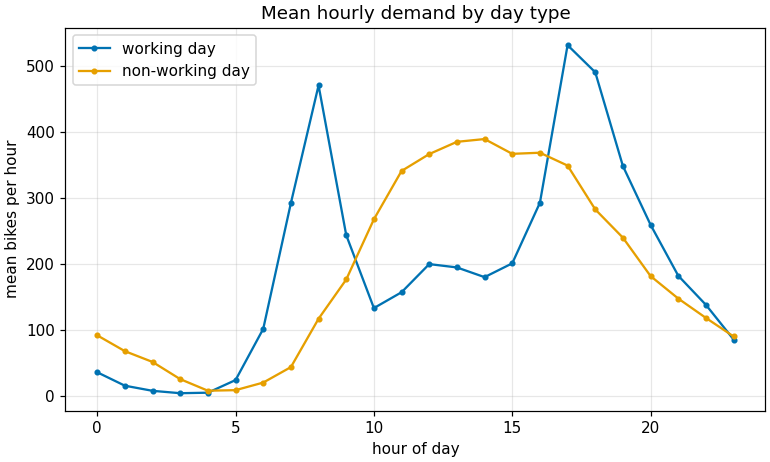

In [3]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plots.plot_demand_profile(train_df))

In [4]:
quirks = pd.Series({
    "rows with hum == 0": int((train_all["hum"] == 0).sum()),
    "share of rows with windspeed == 0": round(float((train_all["windspeed"] == 0).mean()), 4),
    "rows with weathersit == 1": int((train_all["weathersit"] == 1).sum()),
    "rows with weathersit == 2": int((train_all["weathersit"] == 2).sum()),
    "rows with weathersit == 3": int((train_all["weathersit"] == 3).sum()),
    "rows with weathersit == 4": int((train_all["weathersit"] == 4).sum()),
    "correlation of temp and atemp": round(float(np.corrcoef(train_all["temp"], train_all["atemp"])[0, 1]), 4),
}, name="value")
print(quirks.to_string())

rows with hum == 0                     22.0000
share of rows with windspeed == 0       0.1206
rows with weathersit == 1            7192.0000
rows with weathersit == 2            2834.0000
rows with weathersit == 3             859.0000
rows with weathersit == 4               1.0000
correlation of temp and atemp           0.9849


### What we saw in the data before modelling

We looked at the data first (the scripts are in `exp/eda0/`), and the Expectation cells of the phases were written after this look but before each phase was run.

- **Time structure.** `train.csv` holds days 1-19 of every month of 2011 and 2012; `test.csv` holds the 20th of every month. The hidden test is therefore whole days we have never seen, spread through the same two years. Rows are not independent: hours of one day resemble each other, and every validation row of our seeded split has same-day neighbours in the training portion.
- **Missing hours.** Some hours are absent, mostly between 2 and 5 at night, and `cnt` is never 0. Quiet hours seem to be missing rather than recorded as zero, so our models never see a zero-demand hour.
- **Growth.** Mean demand in 2012 is about 1.65 times that of 2011.
- **Shape.** Working days have two commute peaks (around 8h and 17-18h); other days have one broad midday hump (plot above). An additive model cannot express that.
- **Copies.** `atemp` follows `temp` (r = 0.985); `season` is the calendar quarter of `mnth`; `workingday` is an exact function of `weekday` and `holiday`; `yr`, `instant` and the date all measure time.
- **Quirks.** Humidity is 0 on a single day (sensor failure); wind speed is exactly 0 in about 12% of rows and takes only 28 distinct values; weather situation 4 occurs once.

**Splits.** One seeded 80/20 split (the cell above) is used for every reported score and every tuning decision. Phase 3 adds one chronological split. Folds of whole days inside the training portion, fixed by the calendar rather than by a seed, are used only as a check. `test.csv` is read once, at the very end.

## Expectation — Phase 1: Gradient Descent

*Written before running the phase (see the git history of this file).*

**What we fit.** A linear model for `log1p(cnt)` on 35 standardised columns: 23 hour dummies, `workingday`, `holiday`, two weather-situation dummies, `temp`, `hum`, `windspeed`, a linear trend in days, and two day-of-year harmonics. We fit it with our own gradient descent, starting from zero weights.

**What we expect, and why.**

1. *Convergence.* The MSE loss is a quadratic bowl, so gradient descent is stable only when the learning rate is below 2 / λ_max of XᵀX/n. Our columns are standardised and hour dummies are almost uncorrelated with each other, so we expect λ_max close to 2 and a bound close to 1. With half the bound we expect a smooth, monotone loss curve that stops in a few hundred iterations (not thousands). A learning rate 5% above the bound should blow up; one at 0.1% of the bound should still be far from the minimum after 5,000 iterations.
2. *Correctness.* Our final weights should match the closed-form least-squares weights to better than 1e-3, and the finite-difference gradient check should agree to about 1e-8.
3. *Accuracy.* We expect a validation R² (on bikes) of roughly 0.68–0.73, clearly below what the data allows. The reason is structural: this model adds one hour effect and one working-day effect, but the data's rush-hour peaks (8h, 17–18h) exist only on working days. An additive model has to average the two day types, so we expect its residuals, grouped by hour and day type, to show a clear pattern. That pattern is what Phase 2 should fix.
4. *Train vs validation.* With 36 weights and 8,708 rows we expect almost no gap (under 0.02).
5. *Back-transform.* We will try no correction, Duan's smearing factor and a least-squares factor. The textbook says Duan should help; we suspect it will not, because the large log-residuals sit in quiet night hours while the factor inflates every prediction, including the peaks that dominate R².
6. *Bonus (asymmetric cost).* When under-prediction costs three times as much, the fitted predictions should move up. We expect the share of under-predicted validation hours to fall from about one half to about one third or less, at the price of a higher plain RMSE.

### Justification: representation
- **Target.** We model `log1p(cnt)`. Counts are right-skewed and their spread grows with their level, and effects multiply (a rainy rush hour loses a share of its riders, not a fixed number). R² is still computed on bikes after transforming back.
- **Hour.** One-hot, 23 dummies with hour 0 as reference. As a single number the hour gives a validation R² of only 0.193, because demand does not rise or fall steadily through the day. Six sine/cosine pairs reach 0.715 and the dummies 0.721 (table below). We kept the dummies: slightly better, and each weight reads directly as "the effect of this hour".
- **Weather situation.** Dummies, with category 4 merged into 3 because it has a single training row.
- **`dteday`.** A trend in days since 1 January 2011 (demand grew strongly) and two day-of-year sine/cosine pairs (the season, without a jump between December and January).
- **Cleaning.** Humidity 0 occurs on one day only (a sensor failure); those rows get the training median. Wind speed is left as measured.
- **Left out until Phase 4.** `atemp`, `season`, `mnth`, `yr`, `instant` and `weekday` each repeat information that is already in the design almost exactly (for example `workingday` is an exact function of `weekday` and `holiday`). Duplicates make the weights non-unique and slow gradient descent down. Without them the condition number is 45.5. Phase 4 puts them back and lets the models judge them.
- **Scaling.** Every column is standardised with the training mean and standard deviation only.

In [5]:
p1 = p1mod.run(CFG)   # fits Phase 1 from scratch and writes artifacts/p1.json
print("training rows        :", p1["n_train"], "| validation rows:", p1["n_val"])
print("columns (with bias)  :", p1["n_features"])
print("target               :", p1["target_transform"])
print("first columns        :", ", ".join(p1["feature_names"][:4]), "...")
print("lambda_max of X'X/n  :", round(p1["lambda_max"], 4))
print("stability bound 2/lambda_max:", round(p1["lr_bound"], 4))
print("learning rate used   :", round(p1["lr"], 4), "=", p1["lr_fraction"], "x bound")
print("condition number     :", round(p1["condition_number"], 1))

training rows        : 8708 | validation rows: 2178
columns (with bias)  : 36
target               : log1p
first columns        : bias, hr_1, hr_2, hr_3 ...
lambda_max of X'X/n  : 1.9749
stability bound 2/lambda_max: 1.0127
learning rate used   : 0.5064 = 0.5 x bound
condition number     : 45.5


### Justification: learning rate and stopping rule
- **Learning rate.** For a quadratic loss, gradient descent is stable only below 2 / λ_max of XᵀX/n. We compute λ_max = 1.9749 from our design, so the bound is 1.0127, and we use 0.5 of it: lr = 0.5064. At half the bound every direction of the loss surface shrinks without overshooting, so the loss can only go down, and we keep a factor-two safety margin.
- **Evidence that it converges rather than stalls or diverges.** The sweep below uses the same data and start. At 0.001 and 0.01 of the bound the run is still far from finished after 5000 iterations (stall). At 0.1 it converges but needs 2388 iterations. Our setting needs 474. At 0.9 it is faster (261) but leaves almost no margin. At 1.05 the loss explodes and the run is stopped after 94 iterations (diverge).
- **Stopping rule.** We stop when the relative change of the loss is at most 1e-10 and the gradient norm is below 1e-06, with a cap of 50000 iterations. The loss test alone can fire on a flat stretch far from the minimum; the gradient test alone depends on the scale of the problem; together they mean "flat because we are at the bottom".
- **Start.** Zero weights, so anyone who re-runs this cell gets exactly the same weight vector.

In [6]:
sweep = pd.DataFrame([{"fraction of bound": r["fraction"], "lr": r["lr"], "stop": r["stop_reason"],
                       "iterations": r["iterations"], "final loss": r["loss_final"]} for r in p1["lr_sweep"]])
print(sweep.round(4).to_string(index=False))

 fraction of bound     lr      stop  iterations   final loss
             0.001 0.0010  max_iter        5000 1.778000e-01
             0.010 0.0101  max_iter        5000 1.666000e-01
             0.100 0.1013 converged        2388 1.664000e-01
             0.500 0.5064 converged         474 1.664000e-01
             0.900 0.9115 converged         261 1.664000e-01
             1.050 1.0634  diverged          94 1.196472e+07


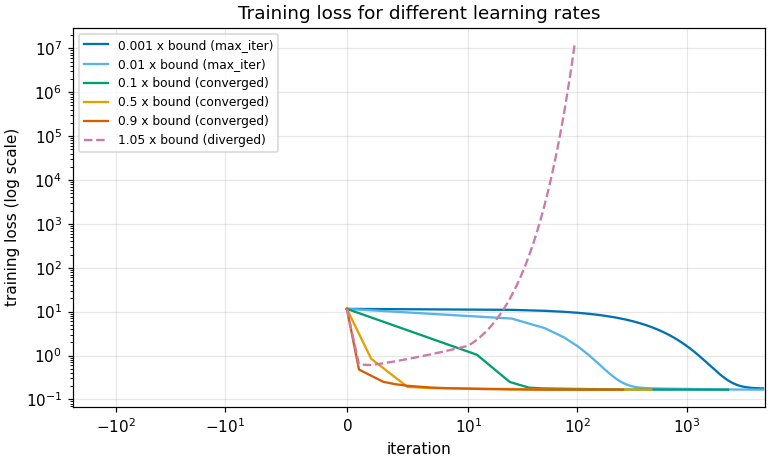

In [7]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plots.plot_lr_sweep(p1))

stop reason : converged
iterations  : 474
final loss  : 0.166405
gradient norm at the end: 9.853358279925282e-07 (tolerance 1e-06 )


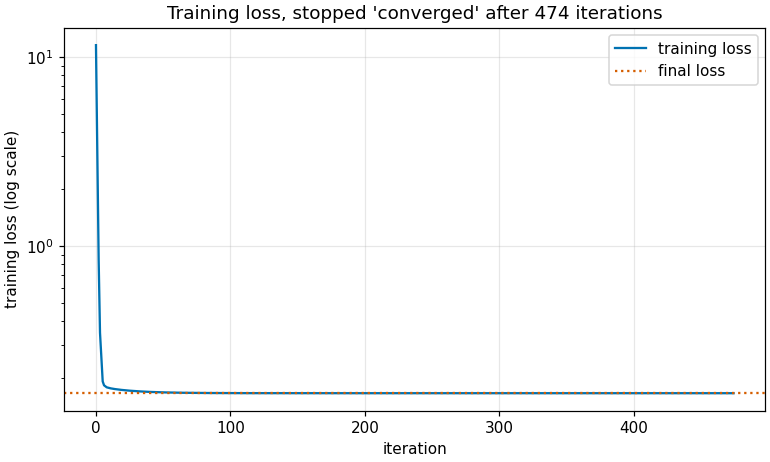

In [8]:
print("stop reason :", p1["stop_reason"])
print("iterations  :", p1["iterations"])
print("final loss  :", round(p1["train_loss_final"], 6))
print("gradient norm at the end:", p1["grad_norm_final"], "(tolerance", p1["tol_grad"], ")")
show(plots.plot_loss_curve(p1))

In [9]:
oracle = p1["oracle"]
print(oracle["label"])
print("largest weight difference:", oracle["max_abs_weight_diff"])
print("loss gap (GD minus exact):", oracle["loss_gap"])
print("validation R2 difference :", oracle["val_r2_diff"])
print("gradient check (max relative error): at zeros", p1["gradient_check_at_zeros"],
      "| at a random point", p1["gradient_check_at_random"])

oracle: np.linalg.lstsq, used only to check GD
largest weight difference: 5.022187835213021e-06
loss gap (GD minus exact): 1.1182471615356349e-11
validation R2 difference : -7.0590433498551874e-09
gradient check (max relative error): at zeros 4.6136799075966205e-07 | at a random point 4.239939060146219e-08


### Justification: back-transform
The model predicts log-bikes; `exp(prediction) − 1` systematically under-shoots the mean of `cnt`. We compared three corrections, each fitted on the training rows and judged on validation: no factor (R² 0.7181, mean prediction 0.921 of the true mean), Duan's smearing factor 1.167 (R² 0.6956, mean ratio 1.076), and a least-squares factor 1.041 (R² 0.7212, mean ratio 0.959). Duan over-corrects: the big log-errors are in quiet night hours, but the factor multiplies the peaks too. We keep the least-squares factor, s = Σ(cnt+1)·e^η / Σ e^{2η}, which is the multiplier that minimises squared error on bikes. The method is now fixed for every later phase; each phase recomputes the factor from its own training residuals.

In [10]:
candidates = pd.DataFrame(p1["backtransform"]["candidates"]).T
candidates.index.name = "method"
print(candidates.round(4).to_string())
print("chosen:", p1["backtransform"]["method"], "with factor", round(p1["backtransform"]["factor"], 4))

        factor  val_mean_ratio  val_r2  val_rmse
method                                          
duan    1.1672          1.0757  0.6956  101.6868
ls      1.0413          0.9591  0.7212   97.3189
none    1.0000          0.9209  0.7181   97.8585
chosen: ls with factor 1.0413


In [11]:
boot = p1["val_bootstrap"]
scores = pd.DataFrame({"R2": [p1["train_r2"], p1["val_r2"]], "RMSE": [p1["train_rmse"], p1["val_rmse"]],
                       "R2 on log1p(cnt)": [p1["train_r2_log"], p1["val_r2_log"]]}, index=["train", "validation"])
print(scores.round(4).to_string())
print(f"validation R2 95% interval: [{boot['lo']:.4f}, {boot['hi']:.4f}] (standard error {boot['se']:.4f})")

                R2     RMSE  R2 on log1p(cnt)
train       0.7293  93.8172            0.8341
validation  0.7212  97.3189            0.8233
validation R2 95% interval: [0.6938, 0.7480] (standard error 0.0141)


In [12]:
ablation = pd.DataFrame(p1["hour_encoding_ablation"]).T[["n_features", "val_r2", "iterations", "stop_reason"]]
ablation.index.name = "hour encoding"
print(ablation.to_string())

              n_features    val_r2 iterations stop_reason
hour encoding                                            
harmonics6            25  0.715052        196   converged
numeric               14  0.192812        193   converged
one_hot             36.0  0.721198        NaN         NaN


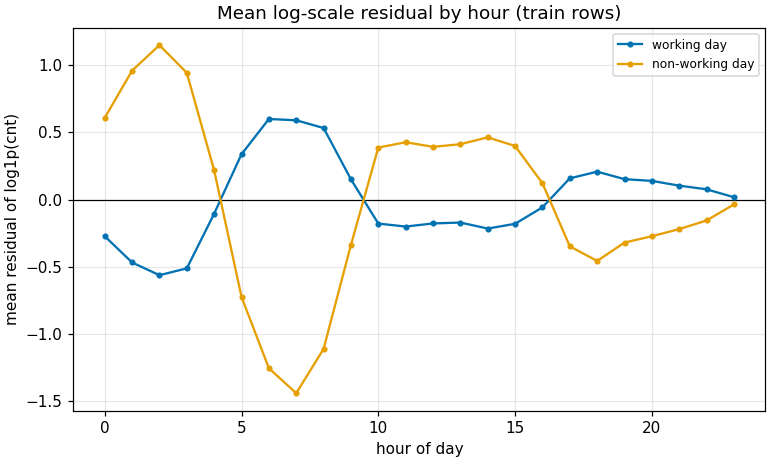

In [13]:
show(plots.plot_residual_profile(p1))

### Justification: bonus
**The operator's cost.** Under-predicting by some amount costs three times as much as over-predicting by the same amount. We read this as a weighted squared error on bikes (the cost is paid in bikes, not log-bikes):

L(w) = (1/n) Σ cᵢ (ŷᵢ − yᵢ)², with ŷᵢ = exp(xᵢ·w) − 1 and cᵢ = 3 if ŷᵢ < yᵢ, else 1.

**Gradient.** By the chain rule, ∂ŷᵢ/∂w = exp(xᵢ·w)·xᵢ, so ∇L = (2/n) Σ cᵢ (ŷᵢ − yᵢ) exp(xᵢ·w) xᵢ. The weight cᵢ jumps only where the residual is zero, so it adds nothing to the gradient. Our finite-difference check agrees to 1.8e-09.

**Optimiser.** This loss is no longer a quadratic, so the fixed-step bound of the MSE model does not apply. We keep plain gradient descent but choose each step by backtracking (halve the step until the loss decreases enough), starting from the Phase 1 MSE weights. It stopped as "converged" after 4376 iterations. The absolute-error version of the same cost is shown in the table as a sensitivity check. This model is a side study: Phase 2 receives the MSE weights.

In [14]:
bonus = p1["bonus"]
compare = pd.DataFrame(bonus["val"]).T[["sq_cost", "abs_cost", "under_share", "mean_error", "r2", "rmse", "mean_pred"]]
print(f"asymmetric cost with k = {bonus['k']:g}: {bonus['iterations']} iterations, stop reason {bonus['stop_reason']}")
print("gradient check of the asymmetric loss:", bonus["gradient_check"])
print(compare.round(4).to_string())
print("mean prediction ratio asymmetric / MSE:", round(bonus["mean_shift_ratio"], 4))

asymmetric cost with k = 3: 4376 iterations, stop reason converged
gradient check of the asymmetric loss: 1.780909948839783e-09
               sq_cost  abs_cost  under_share  mean_error      r2     rmse  mean_pred
asym_model  14055.5392  103.2242       0.3044     34.7367  0.7064  99.8666   226.1775
mse_model   22182.7380  142.1198       0.5184    -15.1464  0.7181  97.8585   176.2943
mean prediction ratio asymmetric / MSE: 1.283


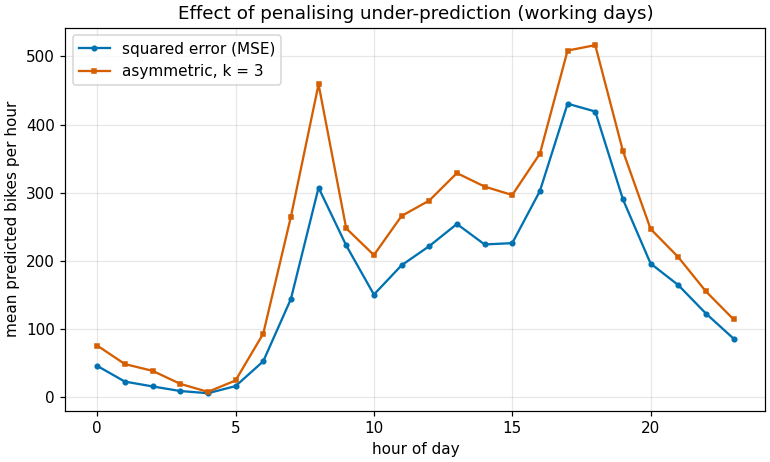

In [15]:
show(plots.plot_bonus_shift(p1))

## Outcome — Phase 1

**What happened.**
- Gradient descent converged in 474 iterations at lr = 0.5064 (λ_max 1.975, as expected close to 2). The weights differ from the closed-form solution by at most 5.0e-06 and the gradient check agrees to 4.6e-07.
- Validation R² is 0.7212 (95% interval 0.694–0.748), RMSE 97.3 bikes; training R² is 0.7293, so there is essentially no gap, as expected for 36 weights.
- The residual plot shows the pattern we predicted: on non-working days the model is far too low at night and too high at commute hours, because it has one hour profile for both day types.
- Bonus: with the 3:1 cost the mean prediction rises by a factor of 1.28; the share of under-predicted validation hours falls from 0.52 to 0.30 and the asymmetric cost from 22183 to 14056, while plain RMSE worsens from 97.9 to 99.9.

**What surprised us.**
- Duan's factor was not just unhelpful, it cost 0.718 → 0.696 in R². A small least-squares factor was the best of the three, which we had not expected to differ from "no factor".
- The hour as a plain number was even worse than we thought (R² 0.19): in log space the night trough dominates and a straight line through 0–23 cannot follow it.
- The plain MSE model under-predicts more than half of the hours (0.52) and is -15 bikes low on average. A log-scale fit aims at the median, not the mean, so for an operator who fears empty docks the "neutral" model is already biased the wrong way.

**Handed to Phase 2:** the weight vector, the scaler, lr rule and stopping rule in `artifacts/p1.json`.

## Expectation — Phase 2: Polynomial Regression

*Written before running the phase (see the git history of this file).*

**What we do.** We load the Phase 1 weight vector from `artifacts/p1.json`, expand the design, and continue our own gradient descent from those weights (new columns start at zero).

**What we expect, and why.**

1. *The chain.* Because the 35 base columns keep the Phase 1 scaler and every new weight starts at zero, the very first loss of Phase 2 must equal the last loss of Phase 1 to about 1e-9. If it does not, the hand-over is broken.
2. *Which terms matter.* The degree-2 products `workingday × hour` (23 columns) should give by far the largest gain, because they let the hour profile differ between working and non-working days. We expect validation R² to rise from Phase 1's level to about 0.89 from this block alone.
3. *Powers.* Demand rises with temperature and then flattens, and falls with humidity, so squares and cubes of `temp` and `hum` should add a little more (about +0.02). We expect powers of `windspeed` to add nothing measurable. We do not expand `trend`: a power of time would extrapolate badly.
4. *Degree.* We expect the curve of validation R² against degree to flatten after degree 2 or 3; degree 4 should not beat degree 3 by more than 0.001. Our rule, fixed in advance, is to take the smallest degree within 0.001 of the best.
5. *Optimisation.* Powers of a variable are correlated with each other and the interaction columns are correlated with the hour dummies, so the expanded design is worse conditioned. We expect roughly ten times more iterations than Phase 1 (a few thousand) at the same "half the bound" learning rate, still with a monotone loss.
6. *Fit quality.* Training and validation R² should stay within about 0.01 of each other: 60–70 weights are still few for 8,708 rows. If so, this model is more likely under-fit than over-fit, which is the question for Phase 3.

### Justification: initialisation from Phase 1
The expanded design keeps the 35 Phase 1 columns in the same positions and with the Phase 1 scaler (read from `artifacts/p1.json`, not refitted). Each new column gets its own training mean and standard deviation. The longer weight vector is the Phase 1 vector with zeros in the new positions. A zero weight switches a column off, so the expanded model starts as exactly the Phase 1 model: its first loss must equal Phase 1's last loss. The cell below checks this to 1e-9. Starting there instead of at random also means gradient descent only has to learn the correction that the new columns allow.

In [16]:
p2 = p2mod.run(CFG)   # reads artifacts/p1.json, fits Phase 2 and writes artifacts/p2.json
difference = p2["init_loss"] - p1["train_loss_final"]
print("Phase 1 final training loss :", repr(p1["train_loss_final"]))
print("Phase 2 initial loss        :", repr(p2["init_loss"]))
print("difference                  :", difference)
assert abs(difference) <= 1e-9, "the hand-over from Phase 1 to Phase 2 is broken"
print("hand-over check passed (|difference| <= 1e-9)")

Phase 1 final training loss : 0.16640496154638676
Phase 2 initial loss        : 0.16640496154638676
difference                  : 0.0
hand-over check passed (|difference| <= 1e-9)


### Justification: what we expanded
We expand only where Phase 1's residuals showed structure.
- **`workingday × hour` (23 degree-2 products).** The Phase 1 residuals differ by day type at almost every hour. Without this block the expanded model reaches only 0.7404 on validation; with it 0.9105 (ablation below). This is the one expansion that matters.
- **Powers of `temp`.** Demand rises with temperature and flattens when it is hot. At the chosen degree, powers of `temp` alone give 0.9105, adding `hum` gives 0.9111 and adding `windspeed` as well gives 0.9108. Differences below 0.001 are far inside the noise of our validation set (standard error 0.0057), so by our rule we keep the smallest set: `temp` only.
- **Not expanded.** Hour dummies, weather dummies and `holiday` are 0/1, so their powers are themselves. `trend` is not raised to a power, because a polynomial in time bends away sharply outside the observed dates. The day-of-year terms are already non-linear.

In [17]:
print("blocks      :", p2["blocks"])
print("power cols  :", p2["power_cols"])
print("columns     :", len(p2["feature_names"]), "(", len(p2["expanded_feature_names"]), "new )")
print("new columns :", ", ".join(p2["expanded_feature_names"][:6]), "...")
print("lambda_max  :", round(p2["lambda_max"], 4), "| lr:", round(p2["lr"], 4),
      "| condition number:", round(p2["condition_number"], 1))

blocks      : ['wd_x_hr']
power cols  : ['temp']
columns     : 61 ( 25 new )
new columns : temp^2, temp^3, workingday*hr_1, workingday*hr_2, workingday*hr_3, workingday*hr_4 ...
lambda_max  : 2.7396 | lr: 0.365 | condition number: 64.2


### Justification: degree
"Degree" is the highest total degree of any term: the interaction products are degree 2 and the powers go up to the chosen degree. With every candidate fitted by our own gradient descent from the Phase 1 weights, validation R² is 0.8928 at degree 1 (interactions only), 0.9083 at degree 2, 0.9108 at degree 3 and 0.9107 at degree 4. Our rule, fixed before the run, is the smallest degree within 0.001 of the best: degree 3. The square captures "warmer is better", the cube captures the flattening at high temperature; a fourth power adds nothing. The learning rate is again half the stability bound, recomputed for this design (λ_max 2.740, lr 0.3650), with the same stopping rule as Phase 1.

In [18]:
rows = pd.DataFrame(p2["degree_sweep"])[["degree", "n_features", "iterations", "stop_reason", "train_r2", "val_r2"]]
print(rows.round(4).to_string(index=False))
print("chosen degree:", p2["degree"], "(smallest within", p2["plateau_tol"], "of the best validation R2)")

 degree  n_features  iterations stop_reason  train_r2  val_r2
      1          59         440   converged    0.8921  0.8928
      2          62         475   converged    0.9113  0.9083
      3          65         669   converged    0.9134  0.9108
      4          68         787   converged    0.9136  0.9107
chosen degree: 3 (smallest within 0.001 of the best validation R2)


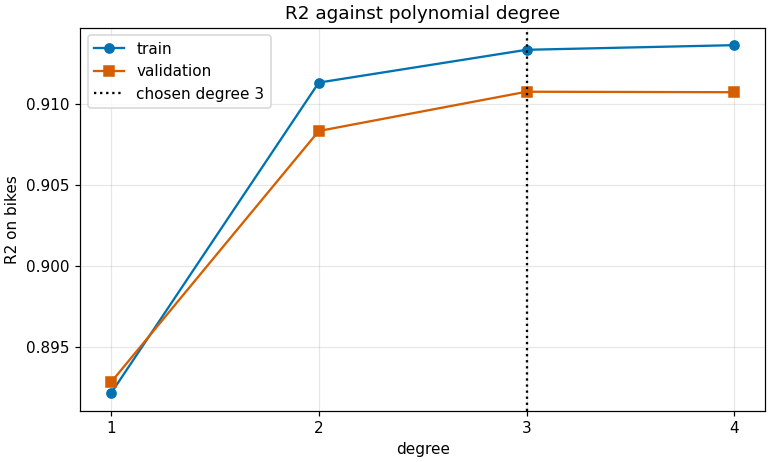

In [19]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plots.plot_degree_sweep(p2))

In [20]:
cols = pd.DataFrame(p2["power_col_sweep"])[["power_cols", "n_features", "iterations", "stop_reason", "train_r2", "val_r2"]]
cols["power_cols"] = cols["power_cols"].apply(lambda c: ", ".join(c))
print(cols.round(4).to_string(index=False))
print("chosen power columns:", p2["power_cols"])

          power_cols  n_features  iterations stop_reason  train_r2  val_r2
                temp          61         611   converged    0.9121  0.9105
           temp, hum          63         641   converged    0.9137  0.9111
temp, hum, windspeed          65         669   converged    0.9134  0.9108
chosen power columns: ['temp']


In [21]:
ablation = p2["block_ablation"]["without_wd_x_hr"]
print("without the workingday x hour block:", ablation["n_features"], "columns, validation R2",
      round(ablation["val_r2"], 4), "(train", round(ablation["train_r2"], 4), ")")
print("with the block                     :", len(p2["feature_names"]), "columns, validation R2",
      round(p2["val_r2"], 4), "(train", round(p2["train_r2"], 4), ")")

without the workingday x hour block: 38 columns, validation R2 0.7404 (train 0.7507 )
with the block                     : 61 columns, validation R2 0.9105 (train 0.9121 )


In [22]:
paired = p2["paired_vs_p1"]
boot = p2["val_bootstrap"]
final = pd.DataFrame({"R2": [p1["val_r2"], p2["val_r2"]], "RMSE": [p1["val_rmse"], p2["val_rmse"]]},
                     index=["Phase 1", "Phase 2"])
print(final.round(4).to_string())
print(f"Phase 2 validation R2 95% interval: [{boot['lo']:.4f}, {boot['hi']:.4f}]")
print(f"gain over Phase 1: {paired['delta']:.4f}, paired 95% interval [{paired['lo']:.4f}, {paired['hi']:.4f}]")
print("stop reason:", p2["stop_reason"], "after", p2["iterations"], "iterations; oracle max weight difference:",
      p2["oracle"]["max_abs_weight_diff"])

             R2     RMSE
Phase 1  0.7212  97.3189
Phase 2  0.9105  55.1504
Phase 2 validation R2 95% interval: [0.8992, 0.9209]
gain over Phase 1: 0.1893, paired 95% interval [0.1649, 0.2156]
stop reason: converged after 611 iterations; oracle max weight difference: 4.745826761701211e-06


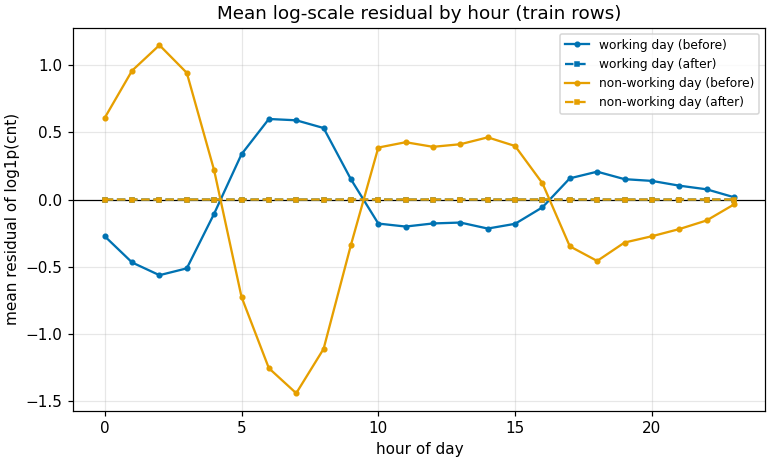

In [23]:
show(plots.plot_residual_profile(p1, p2))

## Outcome — Phase 2

**What happened.**
- The hand-over held exactly: the first Phase 2 loss equals the last Phase 1 loss (0.166405).
- Chosen model: degree 3, powers of `temp`, plus `workingday × hour`: 61 weights. Validation R² rose from 0.7212 to 0.9105 (gain 0.189, paired 95% interval 0.165–0.216); RMSE is 55.2 bikes. Training R² is 0.9121: still no gap.
- As expected, almost all of the gain is the interaction block (degree 1 with interactions already gives 0.8928); the temperature powers add about 0.02, and the curve is flat after degree 3.
- The residual profile by hour and day type is now flat.

**What surprised us.**
- Optimisation was much easier than we feared: 611 iterations, not thousands. We had expected the new columns to be strongly correlated with the old ones, but because we build powers and products from standardised columns the condition number only rose to 64.
- Humidity powers were not worth keeping (0.9105 → 0.9111); we had expected humidity to need a curve as much as temperature does.
- Training and validation R² are almost identical. A model that fits unseen rows as well as its own training rows is not over-fit; the open question for Phase 3 is whether it is still too simple.

**Handed to Phase 3:** degree 3 and the expanded feature list in `artifacts/p2.json`.

## Expectation — Phase 3: Bias–Variance Tradeoff

*Written before running the phase (see the git history of this file).*

**What we do.** We take the Phase 2 design (its degree and feature list, loaded from `artifacts/p2.json`) as the anchor and move complexity both below and above it on a nested ladder of ten designs, from "no hour information" (13 weights) up to "month × working day × hour" (about 900 weights). We also vary the pure polynomial degree, and the amount of training data. Every design is scored three ways: on our seeded validation set, on whole held-out days inside the training portion, and on one chronological split (train before 1 July 2012, validate after).

**What we expect, and why.**

1. *Phase 2 is not over-fit.* Its training and validation R² should differ by less than 0.01. If anything we expect it to be slightly under-fit: letting the weather effect depend on the hour should still raise validation R² by 0.01–0.02.
2. *Degree alone will look flat.* Raising the power of temperature and humidity from 3 to 8 should move neither curve by more than 0.002. A flat line is not evidence of a good fit, which is why we need the wider ladder.
3. *Variance appears late.* On the ladder we expect validation R² to peak somewhere around 250–450 weights and then fall while training R² keeps rising. The first clearly harmful levels should be the month × hour blocks, where many cells hold only a handful of training rows.
4. *Learning curves.* At Phase 2 complexity, validation R² should stop improving after roughly half the training days (a bias signature). At the top of the ladder the train–validation gap should be visibly wider with little data and shrink as data is added (a variance signature).
5. *The time question.* We expect the seeded estimate and the held-out-day estimate to be almost equal (within 0.005). Our model has no way to memorise a particular day, so sharing days between training and validation should hardly help it. The chronological estimate should be clearly lower, by 0.04–0.08, because the model has to extrapolate a growth trend into six months it has never seen, having observed July–December only once.
6. *Which estimate to trust.* For the hidden test set, which is the 20th of each month and so lies inside the observed period, the held-out-day estimate is the right one. For genuinely future months the chronological estimate is the honest one. We expect the diagnosis to stay "bias first, variance only at the top of the ladder" under all three, but the chronological split should prefer a simpler model than the seeded split does, especially disliking the blocks that let the trend vary by hour.

### Justification: what we varied

- **A ladder of nested designs, anchored at Phase 2.** Level C3 is exactly the Phase 2 design, read from `artifacts/p2.json`. Below it we remove what Phase 2 added (C2: no powers; C1: no interactions; C0: no hour at all). Above it we add blocks: weather effects that depend on the hour (C4), a separate hour profile for each weekday (C5), weather detail and weather memory (C6, see the note below), finer weather interactions (C7), hour-specific season and trend (C8), and finally month × hour and month × day type × hour (C9, C10), where many cells contain only a few training rows. Bias shows as "training and validation both low, both rise when we add a block"; variance shows as "training keeps rising, validation falls".
- **The degree alone**, from 1 to 8, with everything else as in Phase 2, because the task asks about the degree; we expected this axis to be flat.
- **The amount of training data** (10% to 100% of the training days) for the anchor, the target and the top level: more data cures variance but not bias.
- **Three ways of scoring** each design: the seeded validation set; five folds of whole held-out days inside the training portion (folds are fixed by the calendar, not by a random seed); and one chronological split.
- **How the sweeps are fitted.** These several hundred fits use the closed-form least-squares solution, which our gradient descent reaches to within 1e-5 in Phases 1 and 2 (the chain cell below checks it again on the anchor); the largest levels would need tens of thousands of iterations each. A tiny ridge term (1e-8) keeps the solution defined where columns are exact copies of each other (`holiday` is determined by the weekday dummies and `workingday`).
- **Note on level C6.** This level was not in our first ladder. After the first complete run we looked at where the C5 model's errors were (working-day rush hours and rainy hours carried about half and a fifth of the squared error) and added the terms that address them: squares and cubes of humidity, wind terms, a temperature effect per working-day hour, and the weather situation one hour earlier and the worst of the previous three hours (wet roads keep riders away after the rain has stopped). These last columns use the weather of neighbouring rows, never their counts. Because this level was designed after looking at validation errors, we judge it mainly by the two estimates that were not used to design it.

In [24]:
# Phase 3 runs everything from artifacts/p1.json and artifacts/p2.json; CFG comes from the setup notebook.
import pandas as pd

from src.common import load_config, read_artifact
from src.phases import p3 as p3mod
from src.plots_p3 import plot_degree_axis, plot_ladder, plot_learning_curves, plot_three_estimates

CFG = globals().get("CFG") or load_config()
p3 = p3mod.run(CFG)  # writes artifacts/p3.json; about 10 seconds

In [25]:
# The chain: the anchor is exactly the Phase 2 design, and our closed-form fit must reproduce its validation R2.
p2 = read_artifact("p2")
print("Phase 2 degree:", p2["degree"], "| features (with bias):", len(p2["feature_names"]))
print("Phase 2 power columns:", p2["power_cols"], "| blocks:", p2["blocks"])
print("Phase 2 validation R2 (gradient descent):", round(p2["val_r2"], 5))
print("anchor validation R2 (closed form here): ", round(p3["ladder"][p3["anchor"]["anchor_index"]]["seeded"]["r2"], 5))
print("anchor_check (closed form - gradient descent):", f"{p3['anchor_check']:.2e}")
print("back-transform method reused from Phase 1:", p3["back_method"])

Phase 2 degree: 3 | features (with bias): 61
Phase 2 power columns: ['temp'] | blocks: ['wd_x_hr']
Phase 2 validation R2 (gradient descent): 0.91046
anchor validation R2 (closed form here):  0.91046
anchor_check (closed form - gradient descent): -7.15e-08
back-transform method reused from Phase 1: ls


In [26]:
# Complexity ladder: three validators per level.
ladder = pd.DataFrame([{"level": r["name"], "weights": r["n_features"], "train_r2": r["seeded"]["train_r2"],
                        "seeded_r2": r["seeded"]["r2"], "gap": r["gap_seeded"], "day_block_r2": r["day_block"]["r2"],
                        "day_block_sd": r["day_block"]["sd"], "chrono_r2": r["chrono"]["r2"]} for r in p3["ladder"]])
print(ladder.round(4).to_string(index=False))
print("target level:", p3["target_level"], "| best on held-out days:", p3["best_level_day_block"],
      "| best chronologically:", p3["best_level_chrono"], "| over-fit from level:", p3["overfit_from_level"])

              level  weights  train_r2  seeded_r2     gap  day_block_r2  day_block_sd  chrono_r2
         C0_no_hour       13    0.1870     0.1748  0.0122        0.1787        0.0413     0.0114
        C1_additive       36    0.7293     0.7212  0.0081        0.7270        0.0148     0.5669
         C2_wd_x_hr       59    0.8921     0.8928 -0.0007        0.8899        0.0116     0.7552
          C3_phase2       61    0.9121     0.9105  0.0016        0.9093        0.0131     0.8577
    C4_hr_x_weather      107    0.9222     0.9227 -0.0004        0.9183        0.0136     0.8850
    C5_weekday_x_hr      251    0.9320     0.9317  0.0004        0.9262        0.0112     0.8929
  C6_weather_detail      282    0.9471     0.9390  0.0081        0.9426        0.0074     0.9141
    C7_fine_weather      332    0.9478     0.9383  0.0096        0.9423        0.0074     0.8997
       C8_hr_x_time      401    0.9477     0.9376  0.0101        0.9415        0.0077     0.8775
      C9_month_x_hr      665  

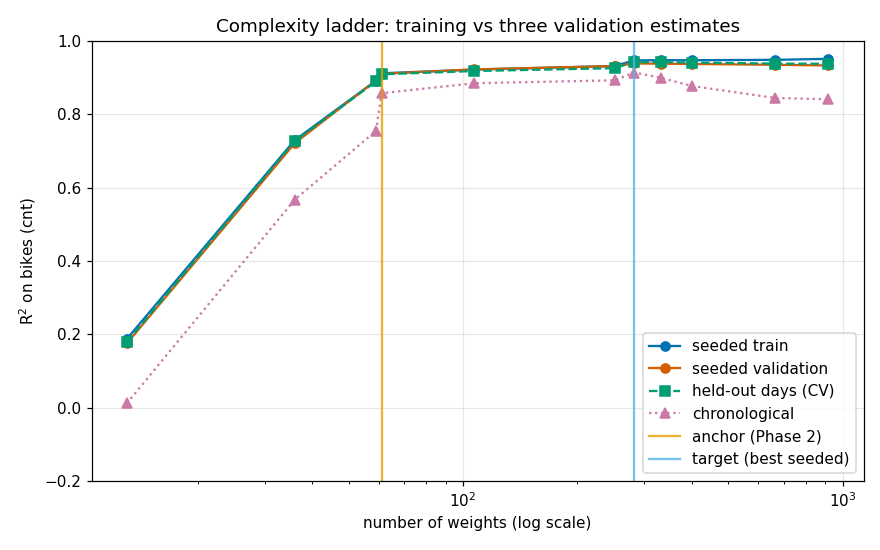

In [27]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plot_ladder(p3))

In [28]:
# Degree axis: anchor blocks and power columns fixed, only the degree changes.
degrees = pd.DataFrame([{"degree": r["degree"], "weights": r["n_features"], "train_r2": r["seeded"]["train_r2"],
                         "seeded_r2": r["seeded"]["r2"], "day_block_r2": r["day_block"]["r2"],
                         "chrono_r2": r["chrono"]["r2"]} for r in p3["degree_axis"]])
print(degrees.round(4).to_string(index=False))
print("range of seeded R2 over degrees >= 2:", round(p3["diagnosis"]["degree_axis_range"], 5))

 degree  weights  train_r2  seeded_r2  day_block_r2  chrono_r2
      1       59    0.8921     0.8928        0.8899     0.7552
      2       60    0.9092     0.9078        0.9064     0.8376
      3       61    0.9121     0.9105        0.9093     0.8577
      4       62    0.9123     0.9099        0.9094     0.8628
      5       63    0.9124     0.9095        0.9096     0.8629
      6       64    0.9125     0.9096        0.9096     0.8621
      8       66    0.9126     0.9097        0.9095     0.8497
range of seeded R2 over degrees >= 2: 0.00262


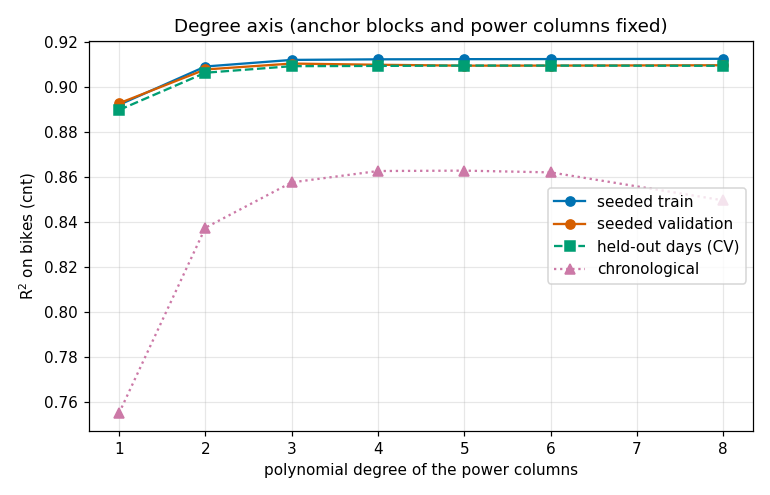

In [29]:
show(plot_degree_axis(p3))

In [30]:
# Learning curves for the anchor, the target and the top of the ladder (clipped at R2 = -0.2 in the plot).
curves = pd.DataFrame([{"design": key, **c} for key, curve in p3["learning_curves"].items() for c in curve])
print(curves.round(4).to_string(index=False))

design  fraction  n_days  n_rows  train_r2   val_r2
anchor       0.1      46     873    0.8849   0.9029
anchor       0.2      91    1729    0.8819   0.9038
anchor       0.4     182    3441    0.8958   0.9069
anchor       0.6     274    5210    0.8997   0.9072
anchor       0.8     365    6939    0.9090   0.9088
anchor       1.0     456    8708    0.9121   0.9105
target       0.1      46     873    0.9348   0.8844
target       0.2      91    1729    0.9295   0.9162
target       0.4     182    3441    0.9315   0.9286
target       0.6     274    5210    0.9390   0.9346
target       0.8     365    6939    0.9435   0.9369
target       1.0     456    8708    0.9471   0.9390
   top       0.1      46     873    0.9853 -17.4616
   top       0.2      91    1729    0.9559   0.3130
   top       0.4     182    3441    0.9445   0.8946
   top       0.6     274    5210    0.9470   0.9175
   top       0.8     365    6939    0.9492   0.9274
   top       1.0     456    8708    0.9516   0.9334


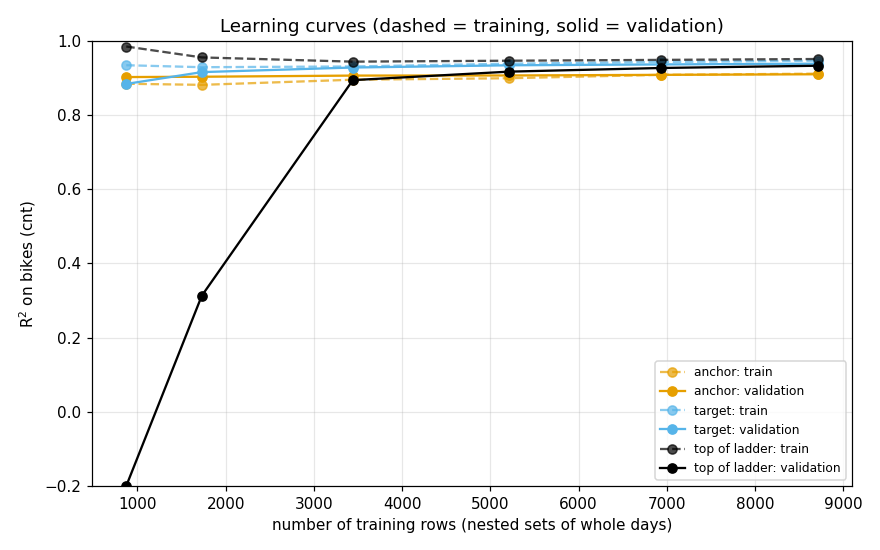

In [31]:
show(plot_learning_curves(p3))

### Justification: the chronological cut

We train on every date before 2012-07-01 (8151 rows) and validate on every date from then on (2735 rows, about a quarter of the file). We put the cut there for three reasons: the held-out part is about the same size as our seeded validation set, so the two estimates are comparably precise; it covers half a seasonal cycle (summer to winter) instead of one season; and the training part still contains one full year plus the first half of the second, so the model has seen each month at least once. A later cut would test only autumn and winter; an earlier one would leave too little of 2012 to learn the growth from.

In [32]:
# Three estimates for the anchor and the target, their gaps, and the bootstrap interval of the seeded estimate.
rows = []
for label, est, gaps in (("anchor", p3["estimates"], p3["gaps"]["anchor"]),
                         ("target", p3["estimates_target"], p3["gaps"]["target"])):
    rows.append({"design": label, "seeded": est["seeded"]["r2"], "ci_lo": est["seeded"]["lo"],
                 "ci_hi": est["seeded"]["hi"], "day_holdout": est["day_holdout"]["r2"],
                 "day_sd": est["day_holdout"]["sd"], "chrono": est["chrono"]["r2"],
                 "leakage_gap": gaps["leakage"], "drift_gap": gaps["drift"]})
print(pd.DataFrame(rows).round(4).to_string(index=False))
print("paired gain target - anchor (seeded):", {k: round(v, 4) for k, v in p3["paired_target_vs_anchor"].items()})

design  seeded  ci_lo  ci_hi  day_holdout  day_sd  chrono  leakage_gap  drift_gap
anchor  0.9105 0.8992 0.9209       0.9093  0.0131  0.8577       0.0012     0.0516
target  0.9390 0.9307 0.9472       0.9426  0.0074  0.9141      -0.0036     0.0285
paired gain target - anchor (seeded): {'delta': 0.0285, 'lo': 0.0206, 'hi': 0.0367}


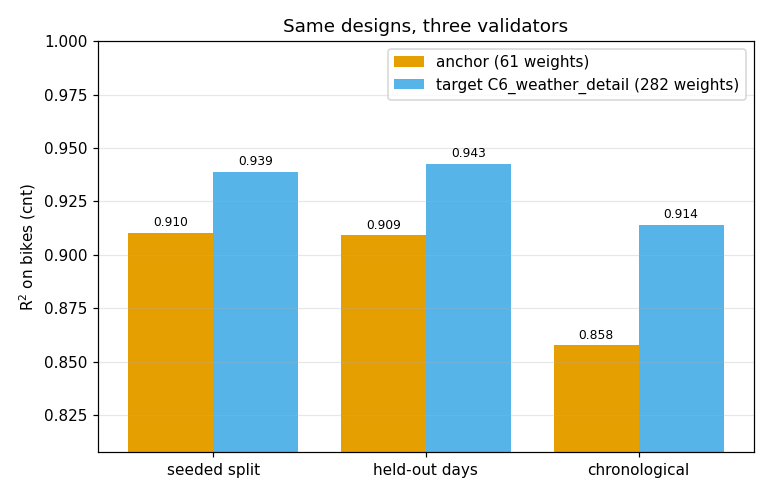

In [33]:
show(plot_three_estimates(p3))

### Justification: which estimate to trust

- **The gap has two possible causes, and we measured them separately.** Seeded versus held-out days isolates the effect of sharing days between training and validation: 0.0012 for the Phase 2 model and -0.0036 for the target, both far smaller than the spread between day folds (0.013). Held-out days versus chronological isolates what changes when the validation period lies in the future: 0.052 and 0.028.
- **So the gap is drift, not leakage.** In the late period the mean demand is 262 bikes against 168 before the cut, and the Phase 2 model's predictions there are 1.11 times the true mean: the straight trend fitted in log space extrapolates growth too steeply. If we only correct that level (a diagnostic, not a usable score) R² returns to 0.900, so most of the gap is the level and the hourly shape still fits.
- **Which one to trust.** For data from new time periods, the chronological estimate (0.858 for Phase 2, 0.914 for the target) is the honest one, and it is the number we would quote to an operator planning next year. The seeded number is the most optimistic of the three. For our hidden test set specifically, which is the 20th of each month inside the two observed years, the held-out-day estimate is the closest match, and it agrees with the seeded one.
- **Does it change the diagnosis?** No in kind, yes in degree: see the Outcome.

In [34]:
# Chronological detail: the late period has a much higher level of demand (growth) than the early one.
detail = pd.DataFrame(p3["chrono_detail"]).T
print(detail.to_string())
print("r2_level_corrected rescales late predictions by the late period's own mean: a diagnostic of level drift only, "
      "not a usable estimate.")

          cut_date n_early n_late mean_cnt_early mean_cnt_late        r2       rmse mean_ratio r2_level_corrected
anchor  2012-07-01    8151   2735     167.785793     262.46947  0.857705  81.536573   1.111328           0.900221
target  2012-07-01    8151   2735     167.785793     262.46947  0.914129  63.340544   1.105637           0.944526
r2_level_corrected rescales late predictions by the late period's own mean: a diagnostic of level drift only, not a usable estimate.


In [35]:
# How much variance is left once the design cells are fully known? (an optimistic ceiling)
for key, value in p3["noise_floor"].items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

noise_floor_r2: 0.9547
noise_floor_r2_adjusted: 0.9350
n_cells: 2636
singleton_cell_share: 0.2986
singleton_row_share: 0.0904


In [36]:
# Diagnosis and target complexity.
for key, value in p3["diagnosis"].items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")
target = p3["target_complexity"]
print("target:", target["level"], "| weights:", target["n_features"], "| degree:", target["degree"],
      "| power columns:", target["power_cols"])
print("blocks:", target["blocks"])

label: under-fit
anchor_gap_train_val: 0.0016
gain_target_over_anchor: 0.0285
gain_ci_lo: 0.0206
gain_ci_hi: 0.0367
day_block_gain: 0.0333
chrono_gain: 0.0564
degree_axis_range: 0.0026
overfit_from_level: 9
target: C6_weather_detail | weights: 282 | degree: 3 | power columns: ['temp']
blocks: ['wd_x_hr', 'hr_x_temp', 'hr_x_hum', 'wk', 'wk_x_hr', 'wx_detail', 'wd_x_hr_x_temp', 'ws_memory']


### Justification: target complexity

Rule: the simplest ladder level whose seeded validation R² is within 0.001 of the best level. It selects C6_weather_detail (282 weights): validation R² 0.9390 against 0.9317 one level below and 0.9383 one level above. The other two estimates agree: held-out days 0.9262 → 0.9426 → 0.9423, chronological 0.893 → 0.914 → 0.900.

We have to be open about two things. First, our original rule was "the level with the highest validation R²". On the first ladder it picked a level 140 weights larger than its neighbour on a difference of 0.0005, which is not a rule we could defend, so we replaced it with the same "smallest within 0.001 of the best" rule we had already fixed for the degree in Phase 2. Second, level C6 itself was added after that first run (see the note above). Both changes are in the git history, and the rule still looks only at the seeded validation set.

## Outcome — Phase 3

**Diagnosis: the Phase 2 model is under-fit (high bias, no measurable variance).**
- Its training and validation R² differ by 0.0016. A model that scores the same on rows it has and has not seen is not over-fit.
- Adding structure raises validation R² from 0.9105 to 0.9390: a gain of 0.029 with a paired 95% interval of 0.021–0.037, confirmed on held-out days (+0.033) and on the chronological split (+0.056). Something real was missing.
- The Phase 2 learning curve is flat: with 10% of the training days validation R² is already 0.903, with all of them 0.910. More data does not help a model that is too simple.
- Variance does exist, but only at the top of the ladder: from level 9 on, training R² keeps rising (0.9516 at C10) while validation falls (0.9334) and the chronological score collapses (0.841); with 10% of the data the top level fails completely and the gap closes as data is added.
- The target itself now shows a small gap (training 0.9471, validation 0.9390) and its learning curve is still rising at full size (0.937 with 80% of the days, 0.939 with all). That is where a little variance begins, and it is what Phase 4 has to watch.

**The time question.** Seeded 0.910, held-out days 0.909, chronological 0.858 for Phase 2; 0.939 / 0.943 / 0.914 for the target. The gap is drift (the future has a higher level of demand than a straight log-trend predicts well), not leakage between hours of the same day. We trust the chronological number for future periods. It does not change the diagnosis, the simpler models are worse on every split, but it does change how far we go: it is the split that punishes the levels above the target most clearly, so it supports stopping there.

**What surprised us.**
- We expected sharing days between training and validation to matter at least a little. It does not (0.0012 for Phase 2; for the target the held-out days even score slightly higher than the seeded set). The warning in the task statement is right in general, but a linear model with a few hundred weights has no way to recognise an individual day, so it cannot profit from its neighbours.
- The chronological split was kinder to the richer target than to Phase 2 (gap 0.028 against 0.052). We had expected the simpler model to travel better through time. Both overshoot the level of the later months; the richer model gets the hourly shape more right.
- The degree axis moved validation R² by only 0.0026 between degree 2 and 8. Had we varied only the degree we would have concluded "reasonably fit" and missed 0.029 of R².
- Our own first selection rule failed on a near-tie, and our first ladder stopped one useful level short; the residuals of the model told us more about what was missing than the ladder we had planned in advance.

**How much is left.** Averaging `cnt` over cells of year, month, day type, hour and weather situation explains 0.935 of the training variance after adjusting for the number of cells. That is a benchmark, not a ceiling: our target already matches it on unseen rows. A diagnostic tree model that we keep outside the pipeline (`exp/analyst/`, never used for any prediction we submit) scored about 0.944 on held-out days, so the target (0.943) is within about 0.002 of what a far more flexible model gets from the same columns. We stop adding structure here.

**Handed to Phase 4:** diagnosis "under-fit", target complexity C6_weather_detail with 282 weights (degree 3). The model we carry forward is not over-fit, but it is the first one with a visible train–validation gap, so we expect regularization to act as insurance with at most a small gain; Phase 4 tests that, including on the over-fit top level.

## Expectation — Phase 4: Regularization (L1, L2, Elastic Net)

*Written before running the phase (see the git history of this file).*

**What we do.** We load the target complexity from `artifacts/p3.json`, add back the six columns we had kept out for conditioning reasons (`atemp`, `yr`, `instant`, `season`, `mnth`, `weekday`), and fit Ridge, Lasso and Elastic Net with our own solvers on exactly the same standardised design, the same training rows and the same grid density. For each method we pick the penalty by validation R² and then check that choice on held-out days and on the chronological split. Finally we judge every original column with drop tests, lasso selection frequency and correlations.

**What we expect, and why.**

1. *Regularization will be a robustness choice, not an accuracy one.* Phase 3 should hand us a model that is not over-fit, so we expect the best penalties to be small and all three methods to land within about ±0.002 validation R² of the unpenalised fit, which is inside the bootstrap noise. We do not expect any method to "win" clearly.
2. *Lasso will not be very sparse.* The signal here is spread over many hour-specific columns. We expect Lasso at its best penalty to keep well over half of the coefficients.
3. *Lasso will be unreliable on duplicates.* `temp` and `atemp` are correlated at 0.985. We expect Lasso to keep both at small penalties, or to pick one of them arbitrarily, and Elastic Net to share the weight between them. This is why a zero from Lasso is only one piece of evidence for us, next to the drop tests and the selection frequency over resampled days.
4. *Where the penalty should matter.* On the most complex ladder level, which Phase 3 should show to be over-fit, we expect a penalty to recover most of the lost validation R², but not to beat the target design by more than the noise.
5. *Column verdicts we predict.* Useful: `hr`, `temp`, `hum`, `weathersit`, and the day-type information. Redundant: `atemp` (carried by `temp`), `season` and `mnth` (carried by the day-of-year terms from `dteday`), `yr` and `instant` (carried by the trend from `dteday`), and at least one of `weekday` / `workingday` / `holiday`, since `workingday` is an exact function of the other two. We are least sure about `windspeed` and `holiday`: their effect may be too small to separate from noise, in which case the honest verdict is "uninformative".
6. *Surprise we are watching for.* If dropping a column we believe to be useful costs nothing, another column is carrying its information and we have the labels the wrong way round.

### Justification: search ranges and strategy

- **How Phase 3 shapes the search.** The diagnosis was "under-fit, no measurable variance" for the model we carry forward. So we do not expect a large penalty to help, and the grid has to reach down to practically zero to show that; we also add the unpenalised fit as a reference line. At the other end the grid must go far enough to show the model being destroyed, so that the optimum is visibly inside the range and not at an edge.
- **Design.** The Phase 3 target design plus the columns we had held back (`atemp`, `yr`, `instant`, `season`, `mnth`; `weekday` is already in the target), so that every original column is in front of the three methods. All columns are standardised on the training rows; the intercept is never penalised.
- **Objective.** (1/2n)‖y − b − Xw‖² + α·ρ‖w‖₁ + (α/2)(1 − ρ)‖w‖², with ρ = 0 for Ridge, ρ = 1 for Lasso and ρ in {0.1, 0.3, 0.5, 0.7, 0.9, 0.95} for Elastic Net. Ridge is solved in closed form; Lasso and Elastic Net by our own cyclic coordinate descent with soft-thresholding, warm-started along the path. Our tests check all three against a reference library to better than 1e-3.
- **Grids.** 40 log-spaced values per path. Ridge: 1e-06 to 1000. Lasso and Elastic Net: from the smallest penalty that sets every weight to zero (computed from the data: 0.559 for Lasso) down to one ten-thousandth of it. Log spacing because the effect of a penalty is multiplicative.
- **Honesty note.** 5 Lasso fits, all at one large grid value far from the chosen one, used the full 20000 sweeps without meeting our tolerance; the exactly duplicated columns in this design make coordinate descent crawl there. None of them is a chosen model.

In [37]:
# Phase 4 loads artifacts/p3.json for the target design, adds the candidate columns and runs everything with our own
# solvers. This is the slowest phase of the notebook: a full run takes about 15 minutes, so the cell below loads the
# stored artifact when the config and the upstream artifact are unchanged (python run.py p4 recomputes it).
import pandas as pd

from src.common import cached_or_run, load_config, read_artifact
from src.phases import p4 as p4mod
from src.plots_p4 import (plot_cv_vs_validation, plot_paths, plot_stability, plot_validation_curves,
                          plot_verdicts)

CFG = globals().get("CFG") or load_config()
p4 = cached_or_run("p4", p4mod.run, CFG, upstream="p3")

loaded cached artifacts/p4.json (same config and upstream artifact); run `python run.py p4` or change CFG to recompute


In [38]:
# The chain: target level from Phase 3, candidate columns added, resulting width (n_features counts the bias column).
p3 = read_artifact("p3")
origin = p4["design_from"]
print("Phase 3 target level:", p3["target_level"], "| weights (with bias):", p3["target_complexity"]["n_features"])
print("design used here    :", origin["level"], "| weights before candidates:", origin["n_features_before_candidates"])
print("candidates added    :", origin["candidates_added"], "| skipped (already present):", origin["candidates_skipped"])
print("weights after candidates (with bias):", p4["n_features"], "| back-transform method:", p4["back_method"])
print("solver tolerance:", p4["solver"]["tol"], "| max sweeps:", p4["solver"]["max_sweeps"],
      "| solutions that used all sweeps:", p4["not_converged"]["count"], p4["not_converged"]["where"])

Phase 3 target level: C6_weather_detail | weights (with bias): 282
design used here    : C6_weather_detail | weights before candidates: 282
candidates added    : ['c_atemp', 'c_yr', 'c_instant', 'c_season', 'c_mnth'] | skipped (already present): ['c_weekday']
weights after candidates (with bias): 299 | back-transform method: ls
solver tolerance: 1e-07 | max sweeps: 20000 | solutions that used all sweeps: 5 {'chrono l1': 1, 'curve l1': 1, 'cv l1 fold 0': 1, 'cv l1 fold 1': 1, 'cv l1 fold 2': 1}


In [39]:
# Baseline: the same design with a negligible penalty (closed-form least squares).
print({k: round(v, 5) for k, v in p4["unregularised"].items()})

{'alpha': 0.0, 'train_r2': 0.94757, 'train_rmse': 41.29209, 'val_r2': 0.93724, 'val_rmse': 46.17348}


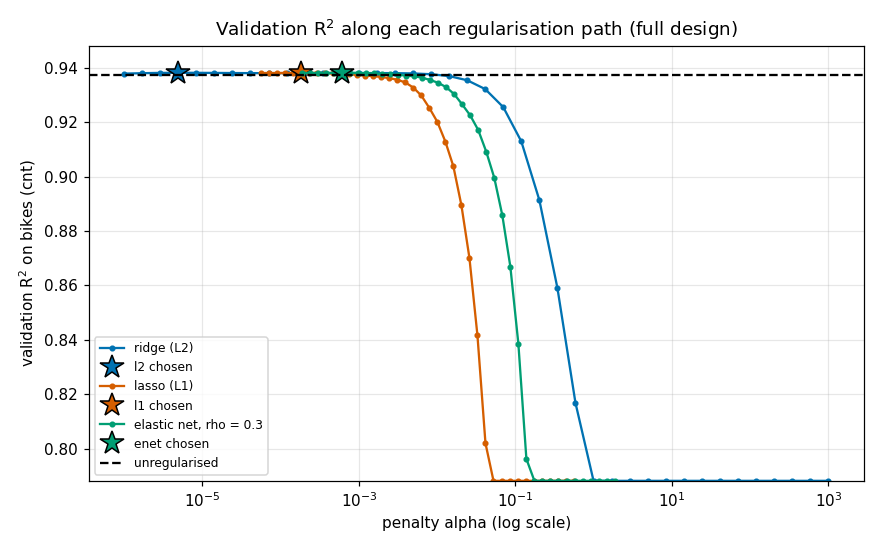

In [40]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plot_validation_curves(p4))

In [41]:
# Chosen hyper-parameters (best validation R2 on each path; ties go to the larger alpha).
chosen = pd.DataFrame([{"method": m, "lambda": v["lambda"], "l1_ratio": v["l1_ratio"], "val_r2": v["val_r2"],
                        "non_zero": v["n_nonzero"], "of": v["n_features"] - 1} for m, v in p4["methods"].items()])
print(chosen.round(5).to_string(index=False))
enet = pd.DataFrame([{"l1_ratio": float(rho), "best_val_r2": max(r["val_r2"] for r in rows),
                      "best_alpha": max(rows, key=lambda r: (r["val_r2"], r["alpha"]))["alpha"]}
                     for rho, rows in p4["curves"]["enet"].items()])
print(enet.round(5).to_string(index=False))

method  lambda  l1_ratio  val_r2  non_zero  of
  enet 0.00061       0.3 0.93817       290 298
    l1 0.00018       1.0 0.93816       288 298
    l2 0.00000       0.0 0.93817       298 298
 l1_ratio  best_val_r2  best_alpha
     0.10      0.93815     0.00144
     0.30      0.93817     0.00061
     0.50      0.93817     0.00036
     0.70      0.93816     0.00026
     0.90      0.93816     0.00020
     0.95      0.93816     0.00019


### Justification: fair comparison of the three methods

The three methods get the same design matrix, the same training rows, the same validation rows, the same day folds, the same number of grid points and the same selection rule. Elastic Net has a second knob and therefore six times as many candidates, which gives it a small advantage on the validation set; that is one reason we do not compare on validation alone. For each method at its chosen setting we report validation R² with a bootstrap interval, the held-out-day R² and the chronological R², and for each pair of methods a paired bootstrap interval of the difference on the same validation rows. A difference whose interval contains zero is a tie.

In [42]:
# Fair comparison: same design, same rows, same grid density; three validators and the paired intervals.
table = pd.DataFrame([{"method": m, "val_r2": v["val_r2"], "val_lo": v["val_lo"], "val_hi": v["val_hi"],
                       "day_block_r2": v["day_block_r2"], "day_block_se": v["day_block_se"],
                       "chrono_r2": v["chrono_r2"], "non_zero": v["n_nonzero"]} for m, v in p4["methods"].items()])
print(table.round(4).to_string(index=False))
diffs = pd.DataFrame([{"comparison": k, **v} for k, v in p4["comparisons"].items()])
print(diffs.round(5).to_string(index=False))
best = p4["full_design_best"]
print("full design (with candidate columns): best on validation:", best["method"], round(best["val_r2"], 5))

method  val_r2  val_lo  val_hi  day_block_r2  day_block_se  chrono_r2  non_zero
  enet  0.9382  0.9296  0.9464        0.9416        0.0032     0.8983       290
    l1  0.9382  0.9296  0.9464        0.9416        0.0032     0.8985       288
    l2  0.9382  0.9296  0.9464        0.9421        0.0031     0.9127       298
              comparison    delta      hi       lo
           enet_minus_l1  0.00001 0.00008 -0.00006
           enet_minus_l2 -0.00000 0.00064 -0.00061
enet_minus_unregularised  0.00093 0.00229 -0.00034
             l1_minus_l2 -0.00001 0.00062 -0.00064
  l1_minus_unregularised  0.00092 0.00231 -0.00039
  l2_minus_unregularised  0.00093 0.00176  0.00012
full design (with candidate columns): best on validation: l2 0.93817


### Justification: choice of lambda per method

For each method we take the penalty with the highest validation R² on bikes (ties go to the larger penalty), because the task says tuning uses the validation set and R² on bikes is the metric we are scored on. Two checks sit beside it in the table below: the penalty that is best on held-out days inside the training portion, and the "one standard error" penalty, the largest one whose held-out-day score is within one standard error of that best. If the validation choice were an accident of this particular split, these would disagree strongly with it. Because we select on the validation rows, the validation scores of this phase are slightly optimistic; the held-out-day and chronological columns are not affected by that.

In [43]:
# Two ways to pick the penalty: best validation R2 versus day-block CV (best and one-standard-error rule).
picks = pd.DataFrame([{"method": m, "validation_best": p4["methods"][m]["lambda"], "cv_best": c["cv_best_alpha"],
                       "cv_1se": c["cv_1se_alpha"], "val_r2_at_cv_best": c["val_r2_at_cv_best"],
                       "val_r2_at_cv_1se": c["val_r2_at_cv_1se"], "val_r2_at_validation_best": p4["methods"][m]["val_r2"]}
                      for m, c in p4["cv"].items()])
print(picks.round(5).to_string(index=False))

method  validation_best  cv_best  cv_1se  val_r2_at_cv_best  val_r2_at_cv_1se  val_r2_at_validation_best
  enet          0.00061  0.00156 0.01032            0.93795           0.93449                    0.93817
    l1          0.00018  0.00047 0.00310            0.93794           0.93560                    0.93816
    l2          0.00000  0.00000 0.02424            0.93785           0.93543                    0.93817


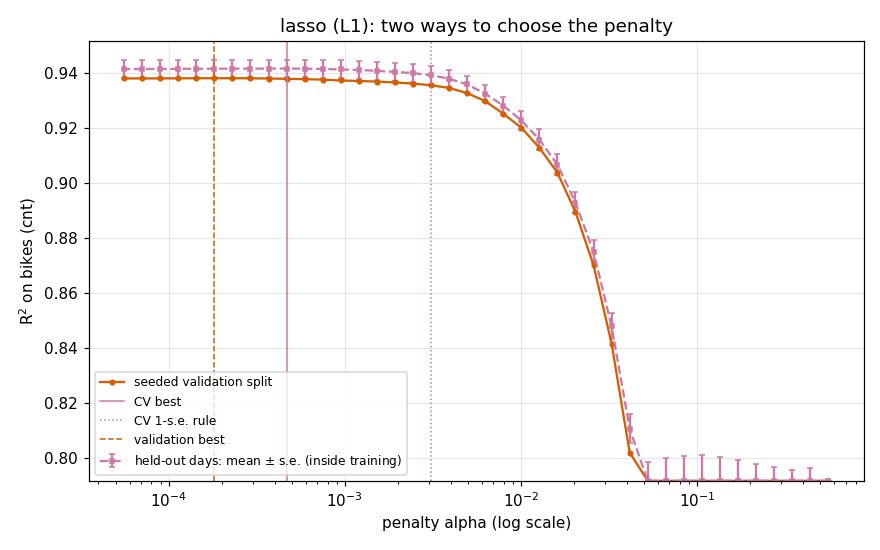

In [44]:
show(plot_cv_vs_validation(p4, "l1"))

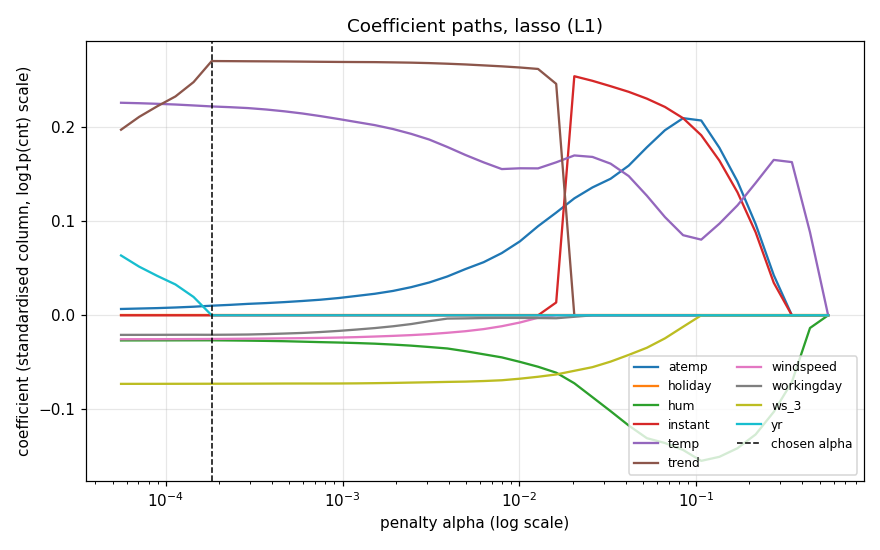

In [45]:
show(plot_paths(p4, "l1"))

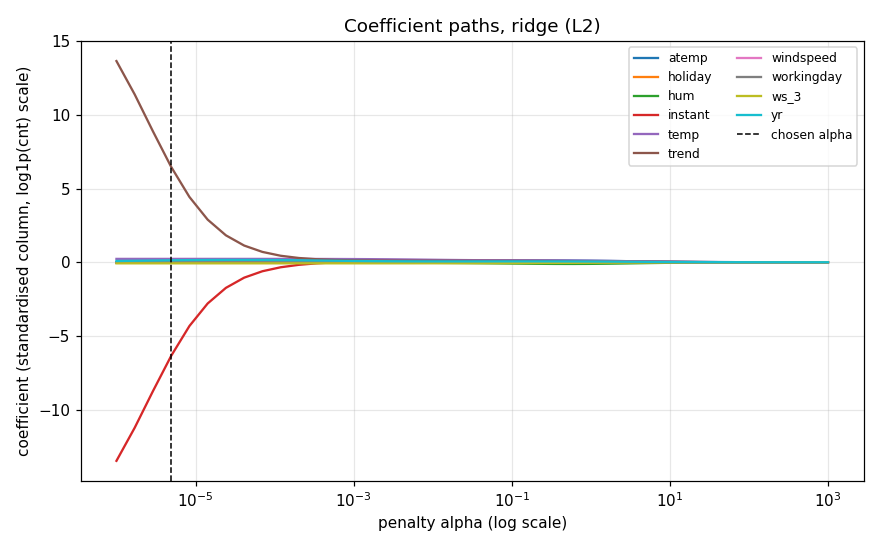

In [46]:
show(plot_paths(p4, "l2"))

In [47]:
# Where does each correlated pair enter the lasso path? (largest alpha with a non-zero weight; None = never)
for name in ("temp", "atemp", "yr", "instant", "trend", "workingday", "holiday"):
    print(f"{name:12s} enters at alpha = {p4['entry_alpha'][name]}")

temp         enters at alpha = 0.44113649312379666
atemp        enters at alpha = 0.2750709841377264
yr           enters at alpha = 0.0001436790670069527
instant      enters at alpha = 0.2750709841377264
trend        enters at alpha = 0.01616871665778034
workingday   enters at alpha = 0.020475742205825154
holiday      enters at alpha = None


### Justification: the verdict rule

We fixed the rule before running the phase. The reference model is Ridge at its chosen penalty on the full design; "dropping" a column means removing every feature built from it (for `hr` that includes all its interactions) and refitting.

- **Useful:** dropping the column alone lowers validation R² by at least 0.001, with a paired bootstrap interval that stays above zero.
- **Redundant:** dropping it alone costs nothing, but either dropping it together with its partner columns hurts, or the column on its own explains at least 0.01 of the variance. Its information is real but another column already carries it. Partners are the groups we measured to be copies of each other: {`temp`, `atemp`}, {`season`, `mnth`, `dteday`}, {`yr`, `instant`, `dteday`}, {`weekday`, `workingday`, `holiday`}.
- **Uninformative:** neither.
- **One representative per group.** If a group matters as a whole but no single member is missed when dropped, we keep the member that explains most on its own and call it useful; the others are redundant "carried by" it.

Lasso evidence is reported next to the drop tests (how many of the column's own features Lasso keeps, how often over 50 resamples of training days, and where it enters the path), but a Lasso zero alone does not decide a verdict: with copies in the design, which copy Lasso keeps is partly arbitrary.

In [48]:
# Verdict for every original column (cost = validation R2 lost when removed; interval = paired bootstrap).
rows = []
for col, v in p4["column_verdicts"].items():
    n = v["numbers"]
    rows.append({"column": col, "verdict": v["verdict"],
                 "alone": f"{n['drop_alone']['delta']:+.4f} [{n['drop_alone']['lo']:+.4f}, {n['drop_alone']['hi']:+.4f}]",
                 "with_partners": None if n["drop_group"] is None else round(n["drop_group"]["delta"], 4),
                 "solo_r2": None if n["solo_r2"] is None else round(n["solo_r2"], 4),
                 "lasso_kept": f"{n['lasso']['n_own_nonzero']}/{n['lasso']['n_own']}",
                 "max_freq": None if n["lasso"]["max_freq_own"] is None else round(n["lasso"]["max_freq_own"], 2),
                 "carried_by": ", ".join(v["carried_by"]), "representative": v["representative"]})
print(pd.DataFrame(rows).to_string(index=False))

    column   verdict                      alone  with_partners  solo_r2 lasso_kept  max_freq          carried_by  representative
     atemp redundant +0.0000 [-0.0000, +0.0001]         0.0293   0.1053        1/1      0.74                temp           False
    dteday    useful +0.0004 [-0.0005, +0.0013]         0.1203   0.1222        3/5      1.00                                True
   holiday redundant +0.0000 [-0.0000, +0.0000]         0.1879   0.0000        0/1      0.72 weekday, workingday           False
        hr    useful +0.6816 [+0.6254, +0.7372]            NaN   0.4896      23/23      1.00                               False
       hum    useful +0.0049 [+0.0017, +0.0079]            NaN   0.0950        3/3      1.00                               False
   instant redundant +0.0002 [-0.0003, +0.0006]         0.1044   0.0864        0/1      0.00              dteday           False
      mnth redundant -0.0012 [-0.0022, -0.0003]         0.0034   0.0606       9/11      0.96     

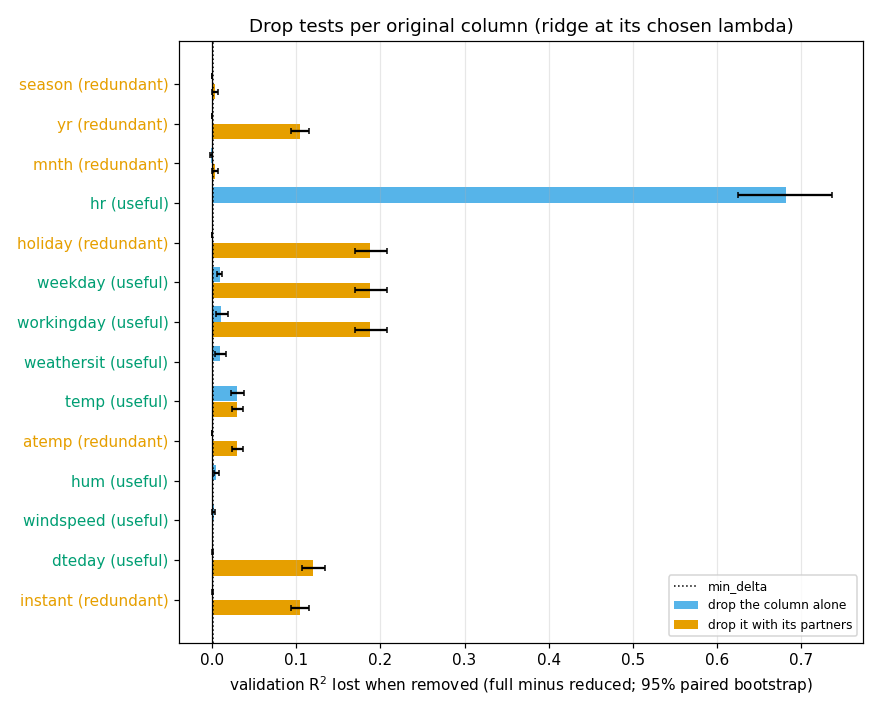

In [49]:
show(plot_verdicts(p4))

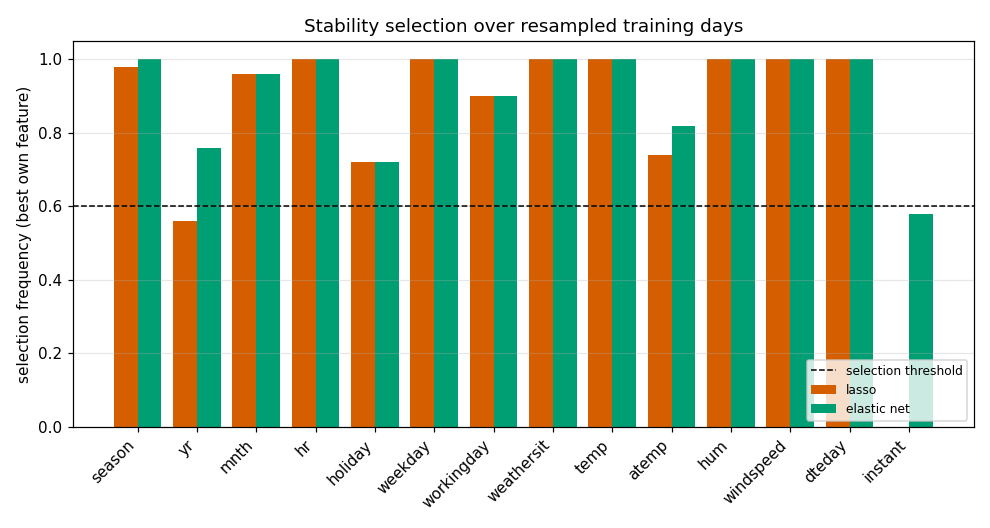

In [50]:
show(plot_stability(p4))

### Justification: the survivor rule

The feature subset handed to Phase 5 is what L1 leaves non-zero, made reproducible. The order matters. We first remove every feature built from a column that is not "useful"; there are 280 features left. On that reduced design we run Lasso again (penalty chosen by validation R²: 1.8e-04), and a feature survives if its weight is non-zero (279 features) and it is selected in at least 0.6 of 50 Lasso fits on resampled training days (279 remain).

Our first version did it the other way round: take the Lasso zeros from the full design, then remove the copies. That turned out to be wrong for a reason worth stating. With month dummies, `yr` and `instant` in the design, Lasso let them stand in for some of the trend and day-of-year terms and zeroed those; the verdict step then removed the stand-ins as redundant, and the survivors had lost part of the time description twice. Validation R² hardly noticed, but the chronological score fell by about 0.013. Lasso should choose among features only after its choices are no longer between copies.

In [51]:
# Survivors: Lasso on the design of useful columns only; non-zero at its chosen lambda and stable over resampled days.
sel = p4["selection"]
print("counts (useful design -> lasso non-zero -> stable):", p4["survivor_counts"])
print("selection lasso: lambda =", round(sel["lambda"], 6), "| val R2 =", round(sel["val_r2"], 4),
      "| non-zero:", sel["n_nonzero"], "of", sel["n_columns"], "| sweeps exhausted:", sel["not_converged"]["count"])
print("original columns kept:", p4["survivors_original"])
print("survivor columns (expanded features):", len(p4["survivors_expanded"]))

counts (useful design -> lasso non-zero -> stable): {'lasso_nonzero': 279, 'stable': 279, 'useful_design': 280}
selection lasso: lambda = 0.000182 | val R2 = 0.939 | non-zero: 279 of 280 | sweeps exhausted: 0
original columns kept: ['hr', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'dteday']
survivor columns (expanded features): 279


### Justification: final model on the surviving columns

Stage A above answers "which columns matter" and needs every column in the design. It is not the model we want to ship: the columns judged redundant add nothing (dropping `mnth` alone changes validation R² by -0.0012, interval -0.0022 to -0.0003; a negative number means the model is better without it), and several of them are extra descriptions of time, which is exactly where our chronological split shows the model to be fragile. So we repeat the same search for the three methods on the surviving columns only (stage B) and recommend among those. Rule, fixed in advance: among the methods whose validation difference to the best is within the paired bootstrap noise, take the one with the best held-out-day R². We added this second stage after seeing the first Phase 4 run; the earlier runs are in the git history.

In [52]:
# Stage B: the same search (ridge, lasso, elastic net) on the surviving columns only.
final = p4["final"]
print("columns:", final["n_columns"], "| solutions that used all sweeps:", p4["not_converged_final"])
table = pd.DataFrame([{"method": m, "lambda": v["lambda"], "l1_ratio": v["l1_ratio"], "val_r2": v["val_r2"],
                       "day_block_r2": v["day_block_r2"], "day_block_se": v["day_block_se"],
                       "chrono_r2": v["chrono_r2"], "non_zero": v["n_nonzero"]} for m, v in final["methods"].items()])
print(table.round(5).to_string(index=False))
print("unregularised on the survivors:", {k: round(v, 5) for k, v in final["unregularised"].items()})
diffs = pd.DataFrame([{"comparison": k, **v} for k, v in final["comparisons"].items()])
print(diffs.round(5).to_string(index=False))
rec = p4["recommended"]
print("within noise of the best:", rec["candidates"], "| recommended:", rec["method"], "| fitted on:", rec["fitted_on"],
      "| lambda:", rec["lambda"], "| l1_ratio:", rec["l1_ratio"])
print("recommended: val R2", round(rec["val_r2"], 5), "| day-block", round(rec["day_block_r2"], 5),
      "| chrono", round(rec["chrono_r2"], 5))

columns: 279 | solutions that used all sweeps: {'count': 0, 'where': {}}
method  lambda  l1_ratio  val_r2  day_block_r2  day_block_se  chrono_r2  non_zero
  enet 0.00077       0.3 0.93901       0.94280       0.00325    0.91415       272
    l1 0.00018       1.0 0.93900       0.94274       0.00328    0.91421       279
    l2 0.00170       0.0 0.93887       0.94274       0.00330    0.91392       279
unregularised on the survivors: {'alpha': 0.0, 'chrono_r2': 0.91392, 'day_block_r2': 0.94259, 'train_r2': 0.94709, 'train_rmse': 41.48012, 'val_r2': 0.93882, 'val_rmse': 45.58706}
                 comparison   delta      hi       lo
best_minus_full_design_best 0.00084 0.00223 -0.00046
              enet_minus_l1 0.00001 0.00011 -0.00010
              enet_minus_l2 0.00014 0.00053 -0.00026
   enet_minus_unregularised 0.00019 0.00073 -0.00038
                l1_minus_l2 0.00013 0.00046 -0.00020
     l1_minus_unregularised 0.00018 0.00065 -0.00029
     l2_minus_unregularised 0.00005 0.00025 -0.0

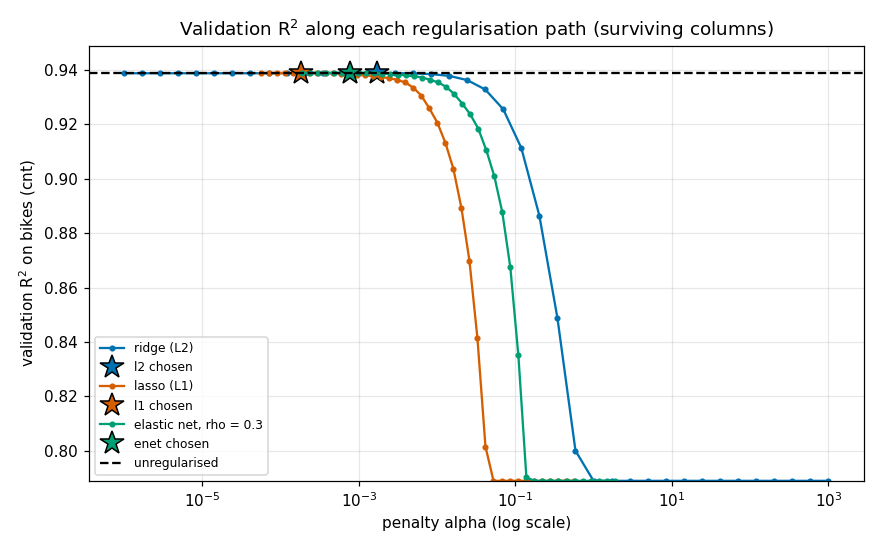

In [53]:
show(plot_validation_curves(p4, stage="final"))

In [54]:
# Does a penalty rescue the over-fit top of the ladder? (informational)
rich = p4["rich_check"]
print(f"level {rich['level']} | weights (with bias): {rich['n_features']} | unregularised val R2: "
      f"{rich['unregularised_val_r2']:.4f}")
for m in ("l2", "l1"):
    print(m, {k: round(v, 5) if isinstance(v, float) else v for k, v in rich[m].items()})
print("best penalised top level minus the recommended (surviving-column) model:",
      {k: round(v, 5) for k, v in rich["paired_best_vs_recommended"].items()})

level C10_month_x_wd_x_hr | weights (with bias): 918 | unregularised val R2: 0.9334
l2 {'day_block_r2': 0.9389, 'lambda': 0.0017, 'val_r2': 0.93384}
l1 {'day_block_r2': 0.94055, 'lambda': 0.00193, 'n_nonzero': 532, 'val_r2': 0.9362}
best penalised top level minus the recommended (surviving-column) model: {'delta': -0.00281, 'hi': 3e-05, 'lo': -0.00568}


## Outcome — Phase 4

**What happened.**
- **The three methods are tied, and none clearly beats the unpenalised fit.** On the full design: Ridge 0.9382, Lasso 0.9382, Elastic Net 0.9382 validation R², against 0.9372 without a penalty; every paired interval between methods contains zero, and the gain over no penalty is about 0.0009. The chosen penalties are tiny (Ridge 4.9e-06, Lasso 1.8e-04, Elastic Net 6.1e-04 with l1_ratio 0.3). As expected after an "under-fit" diagnosis, regularization here is insurance.
- **Where there is variance, the penalty works.** On the over-fit top ladder level Lasso raises validation R² from 0.9334 to 0.9362 while keeping 532 of 918 weights. That is still not better than our recommended model (difference -0.0028, interval -0.0057 to 0.0000).
- **Lasso is not sparse:** it keeps 288 weights. The signal is spread over many hour-specific columns.
- **Verdicts** (table above). Useful: `hr` (dropping it costs 0.682), `temp` (0.0292), `workingday` (0.0103), `weathersit` (0.0092), `weekday` (0.0089), `hum` (0.0049), `windspeed` (0.0016), and `dteday` as the kept representative of time. Redundant: `atemp` (dropping it costs 0.0000, dropping it together with `temp` costs 0.0293), `yr` and `instant` (together with the date terms 0.1044, alone nothing), `season` and `mnth`, and `holiday` (fully determined by `weekday` and `workingday`). No column came out uninformative.
- **Survivors:** 279 features from the eight useful original columns.
- **Final model (stage B):** all three methods again within noise; recommended enet with λ = 7.7e-04: validation R² 0.9390, RMSE 45.5 bikes, held-out days 0.9428, chronological 0.914.

**What surprised us.**
- **Lasso's choices between copies were as arbitrary as we feared, and in one case backwards.** It keeps `atemp` in 0.74 of the resampled fits although dropping `atemp` costs nothing, and it never keeps `instant` (frequency 0.00) although `instant` alone explains 0.086 of the variance. "Lasso set it to zero" was evidence for us, but it would have misled us without the drop tests.
- **`dteday` is useful only as a group.** Dropping the trend and day-of-year terms alone costs 0.0004, because `yr`, `instant`, `season` and `mnth` then step in; dropping them all costs 0.120. We had predicted the copies would be redundant; we had not expected them to be able to replace the original so completely.
- **`mnth` is slightly harmful.** Removing it improves validation R² (see above). Month dummies add steps to a season that the smooth day-of-year terms already describe.
- **`windspeed` is useful after all**, but only because Phase 3's weather-detail level gave it a square and an interaction with temperature. In our first Phase 4 run, with wind as a single linear column, the same rule called it uninformative. A verdict about a column is a verdict about the column *as we represented it*.
- **Our own survivor rule was wrong at first** (see the justification above): taking Lasso zeros before removing the copies quietly cost robustness on later months.
- Some Lasso fits at one large penalty value on the full design ran out of sweeps (5 fits; none is a chosen model). The exactly duplicated columns are the cause; on the survivors every fit converged.

**Handed to Phase 5:** the surviving feature list. Handed to the submission: the stage-B recommended model.

## Expectation — Phase 5: Logistic Regression

*Written before running the phase (see the git history of this file).*

**What we do.** We turn `cnt` into a yes/no target, "is this a high-demand hour?", and train our own logistic regression (gradient descent on the log-loss) using only the feature columns that survived Phase 4, loaded from `artifacts/p4.json`.

**The flaw of a single global threshold, as we see it.** If "high" means "more than the 75th percentile of all hours", then high demand is simply 8 am and 5–6 pm on working days and midday at weekends. A classifier for that label only has to read the clock; it tells the operator nothing they do not already know from the timetable. A threshold per (working day, hour) fixes the clock problem but creates a calendar one: demand grew about 65% from 2011 to 2012, so nearly every "high" hour would be a 2012 hour.

**Our label.** An hour is high-demand when its `cnt` is above the 75th percentile of training hours with the same year, day type and hour of day. The 96 thresholds are computed on the training portion only and looked up for validation rows. "High" then means "busier than three quarters of comparable hours", which is the case where the usual allocation of bikes is not enough.

**What we expect, and why.**

1. *Class balance.* About 25% positives in training and validation, and about the same in each year. The majority-class accuracy is therefore about 0.75, so accuracy alone will flatter any model; we will read F1, precision, recall, ROC-AUC and PR-AUC together.
2. *The foils.* Under the global threshold, hour dummies alone should reach an AUC near 0.85 and the full model near 0.98: impressive and useless. Under the (working day, hour) rule without year, the trend alone should reach about 0.8. Under our rule, hour alone should sit at chance (0.50) and trend alone close to it.
3. *Our classifier.* With the easy cues removed, the model has to rely on weather and season. We expect ROC-AUC between 0.82 and 0.88, well below the foil's number, and we will treat that lower figure as the honest one. Accuracy at a 0.5 cut-off should be only a few points above 0.75.
4. *Operating threshold.* Missing a high-demand hour (empty docks) is worse than a false alarm (a few idle bikes). With the same 3:1 cost ratio as the Phase 1 bonus, the cost-minimising cut-off for a calibrated model is 1/(1+3) = 0.25, not 0.5. We expect recall to rise sharply and precision to fall at 0.25, and the validation cost curve to have its minimum near 0.25 if our probabilities are well calibrated.
5. *Features.* Hour dummies should matter little on their own here, because the label is already relative to the hour; temperature, humidity, weather situation and the day-of-year terms should carry the model.

### Justification: label rule

- **The flaw of one global threshold.** If "high" means "above the 75th percentile of all hours", the label is the timetable: 8h and 17–18h on working days, midday at weekends. In the table below, hour dummies alone then reach a ROC-AUC of 0.855 and the full model 0.986. That looks excellent and tells the operator nothing new.
- **Fixing the clock creates a calendar problem.** With one threshold per (day type, hour), hour alone drops to 0.533, but because demand grew so much, only 0.054 of 2011 validation hours are "high" against 0.421 of 2012 hours, and the trend alone reaches 0.810. Now the label is the year.
- **Our rule.** An hour is high-demand when `cnt` is above the 0.75 quantile of training hours with the same year, day type and hour: 96 thresholds, each from at least 50 training hours, looked up for validation rows. Hour alone is at chance (0.502), trend alone nearly so (0.577), and the positive share is the same in both years (0.239 and 0.262).
- **Why this is meaningful for the operator.** The operator already plans for rush hours and for growth. What they cannot read off a timetable is whether *this* 8 am will be busier than a normal 8 am this year. The top quarter of comparable hours is where a normal allocation of bikes runs short.
- **Why the 75th percentile.** It keeps enough positives to learn from (about a quarter) while still meaning "clearly above normal"; a 90th percentile would leave about five positives in the smallest cells.
- **Limit.** A new year has no cell of its own; in use, the thresholds would have to be rolled forward, for example last year's cell scaled by the fitted trend.

In [55]:
# Phase 5 loads artifacts/p4.json for the surviving columns, builds the label with thresholds fitted on the training
# rows, and fits our own logistic regression. A full run takes about three minutes (the l2 sweep and the label-rule
# foils), so the cell loads the stored artifact when config and upstream are unchanged.
import pandas as pd

from src.common import cached_or_run, load_config, read_artifact
from src.phases import p5 as p5mod
from src.plots_p5 import plot_calibration, plot_label_variants, plot_roc_pr, plot_threshold_curve

CFG = globals().get("CFG") or load_config()
p5 = cached_or_run("p5", p5mod.run, CFG, upstream="p4")  # writes artifacts/p5.json when it has to run

loaded cached artifacts/p5.json (same config and upstream artifact); run `python run.py p5` or change CFG to recompute


In [56]:
# The chain: every feature of this phase must be a survivor of Phase 4.
p4 = read_artifact("p4")
survivors = set(p4["survivors_expanded"])
assert set(p5["features"]) <= survivors, "Phase 5 uses a column that Phase 4 dropped"
print("Phase 4 surviving columns :", len(survivors), "from original columns", p4["survivors_original"])
print("Phase 5 features (no bias):", len(p5["features"]), "| all in the Phase 4 survivors: True")
print("columns incl. bias        :", p5["n_features"], "| training rows:", p5["n_train"], "| validation rows:", p5["n_val"])

Phase 4 surviving columns : 279 from original columns ['hr', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'dteday']
Phase 5 features (no bias): 279 | all in the Phase 4 survivors: True
columns incl. bias        : 280 | training rows: 8708 | validation rows: 2178


In [57]:
# The label: high demand = cnt above the quantile of training hours with the same year, day type and hour.
rule = p5["threshold_rule"]
print("quantile:", rule["quantile"], "| cells:", rule["group_by"], "| fitted on:", rule["fitted_on"])
print("number of cells:", rule["n_cells"], "| fewest training hours in a cell:", rule["min_cell_n"])
thresholds = pd.DataFrame(rule["table"])
peaks = thresholds[thresholds["hr"].isin([3, 8, 12, 17])].pivot_table(index=["yr", "workingday"], columns="hr",
                                                                      values="threshold")
print("\nthreshold (bikes) for four hours of the day:")
print(peaks.round(1).to_string())
balance = p5["class_balance"]
print(pd.Series({"positives, train": balance["train"], "positives, validation": balance["val"],
                 "positives, validation 2011": balance["val_by_year"]["0"],
                 "positives, validation 2012": balance["val_by_year"]["1"],
                 "majority-class accuracy": balance["majority_accuracy"]}).round(4).to_string())

quantile: 0.75 | cells: ['yr', 'workingday', 'hr'] | fitted on: train
number of cells: 96 | fewest training hours in a cell: 50

threshold (bikes) for four hours of the day:
hr               3      8      12     17
yr workingday                           
0  0           30.0  101.0  375.5  364.5
   1            6.0  438.0  195.0  552.0
1  0           40.0  170.0  543.0  555.0
   1            6.0  692.0  305.5  812.0
positives, train              0.2455
positives, validation         0.2502
positives, validation 2011    0.2386
positives, validation 2012    0.2615
majority-class accuracy       0.7498


In [58]:
# The foils: the same three models under three label rules. Only the last rule keeps the hour and the trend at chance.
foils = pd.DataFrame(p5["label_variants"])
foils["rule"] = foils["group_by"].map(lambda g: " + ".join(g) or "global")
print(foils[["rule", "pos_train", "pos_val", "pos_val_2011", "pos_val_2012", "auc_hour_only", "auc_trend_only",
             "auc_full", "acc_full_at_0_5", "majority_accuracy"]].round(3).to_string(index=False))
print("foil fits that did not converge:", p5["foil_not_converged"])

                rule  pos_train  pos_val  pos_val_2011  pos_val_2012  auc_hour_only  auc_trend_only  auc_full  acc_full_at_0_5  majority_accuracy
              global      0.250    0.239         0.154         0.321          0.855           0.662     0.986            0.949              0.761
     workingday + hr      0.245    0.240         0.054         0.421          0.533           0.810     0.937            0.893              0.760
yr + workingday + hr      0.246    0.250         0.239         0.262          0.502           0.577     0.886            0.828              0.750
foil fits that did not converge: []


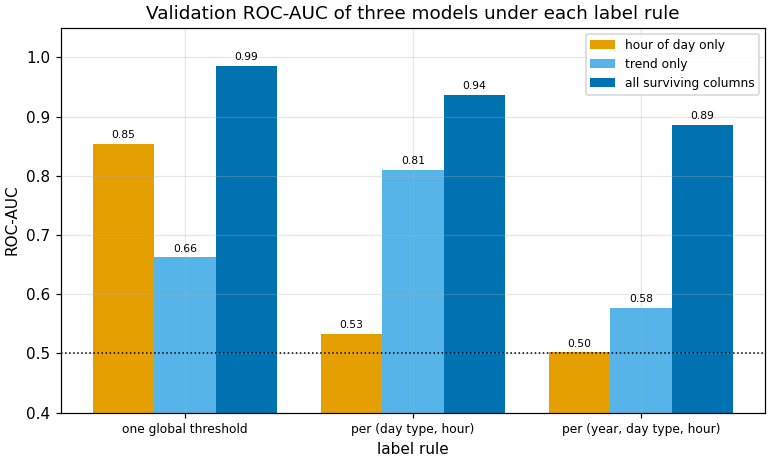

In [59]:
from src.plots import show  # displays a figure as a PNG in the notebook
show(plot_label_variants(p5))

### Justification: regularisation of the classifier

The classifier is our own logistic regression: gradient descent on the mean log-loss, with the step 1/(λ_max/4 + l2), which is the safe step for this loss because its curvature is at most a quarter of that of the squared loss. It uses only the Phase 4 survivors (the assert above). We add a small ridge term because, without any penalty, some weights of rarely active columns keep growing and gradient descent does not settle (the l2 = 0 row below stops at the iteration cap). The strength is chosen by validation ROC-AUC among 0.0, 0.0001, 0.001 and 0.01; ties within 0.0001 go to the larger value. Chosen: 0.0001.

In [60]:
# Ridge strength by validation ROC-AUC (ties within 1e-4 go to the larger l2); the cost of each fit is its iterations.
sweep = pd.DataFrame(p5["l2_sweep"])
print(sweep.round(5).to_string(index=False))
print("\nchosen l2:", p5["l2"], "| iterations:", p5["iterations"], "| stop:", p5["stop_reason"],
      "| learning rate:", round(p5["lr"], 4))
print("gradient check (max relative error): at zeros", f"{p5['gradient_check_at_zeros']:.1e}",
      "| halfway to the final weights", f"{p5['gradient_check_at_half']:.1e}")

 iterations     l2 stop_reason  train_logloss  val_logloss  val_roc_auc
      50000 0.0000    max_iter        0.30813      0.36358      0.88524
      15193 0.0001   converged        0.30821      0.36046      0.88586
       3936 0.0010   converged        0.30990      0.35710      0.88558
        578 0.0100   converged        0.32742      0.36325      0.88007

chosen l2: 0.0001 | iterations: 15193 | stop: converged | learning rate: 1.1586
gradient check (max relative error): at zeros 8.5e-08 | halfway to the final weights 4.0e-08


### Justification: metrics

About one hour in four is positive, so a model that always answers "normal" has an accuracy of 0.750. Accuracy alone would flatter us, so we read it together with: **recall** (how many high-demand hours we catch, the operator's main concern), **precision** (how many alarms are real), **F1** (their balance), **ROC-AUC** (ranking quality, independent of the cut-off and of the class balance) and **PR-AUC** (ranking quality on the positive class, more demanding when positives are the minority). The task's three required numbers, accuracy, F1 and ROC-AUC, are reported at our operating cut-off; the others are shown beside them.

In [61]:
# Metrics on the validation rows at the cost threshold 1/(1+c), at 0.5 and at the F1-optimal grid threshold.
columns = ["threshold", "accuracy", "f1", "precision", "recall", "roc_auc", "pr_auc", "cost"]
table = pd.DataFrame({"at 1/(1+c)": p5["metrics"], "at 0.5": p5["metrics_at_0_5"],
                      "at F1-optimal": p5["metrics_at_f1_opt"]}).T[columns]
print(table.round(4).to_string())
print("\nmajority-class accuracy:", round(p5["class_balance"]["majority_accuracy"], 4))
print("validation ROC-AUC 95% interval:", round(p5["val_auc_bootstrap"]["lo"], 4), "to",
      round(p5["val_auc_bootstrap"]["hi"], 4))
print("training rows at 1/(1+c):", {k: round(v, 4) for k, v in p5["train_metrics"].items()})
conf = p5["metrics"]["confusion"]
print("\nconfusion matrix at 1/(1+c) (rows = truth):")
print(pd.DataFrame([[conf["tn"], conf["fp"]], [conf["fn"], conf["tp"]]], index=["truly normal", "truly high"],
                   columns=["predicted normal", "predicted high"]).to_string())

              threshold  accuracy        f1 precision    recall   roc_auc    pr_auc      cost
at 1/(1+c)         0.25  0.789256  0.662748  0.552696  0.827523  0.885864  0.728701  0.297062
at 0.5              0.5  0.828283  0.632613  0.680761  0.590826  0.885864  0.728701  0.376492
at F1-optimal       0.3  0.801194  0.667179  0.574074   0.79633  0.885864  0.728701  0.300735

majority-class accuracy: 0.7498
validation ROC-AUC 95% interval: 0.8704 to 0.9005
training rows at 1/(1+c): {'accuracy': 0.8138, 'f1': 0.6962, 'roc_auc': 0.9151}

confusion matrix at 1/(1+c) (rows = truth):
              predicted normal  predicted high
truly normal              1268             365
truly high                  94             451


### Justification: operating threshold

A missed high-demand hour means empty docks and lost customers; a false alarm means a few idle bikes. We use the same 3:1 cost ratio as in the Phase 1 bonus. For a model whose probabilities are calibrated, raising an alarm is worth it when p × 3 > (1 − p) × 1, that is when p > 1/(1+3) = 0.25. So our cut-off is 0.25, not the habitual 0.5. The plot below checks the argument on the validation rows: the cost is lowest at 0.25 on our grid, and the calibration plot further down shows how far the probabilities can be trusted (largest gap 0.104).

cost ratio (miss : false alarm): 3.0 | 1/(1+c) = 0.25
grid threshold with the lowest validation cost: 0.25 | with the highest F1: 0.3


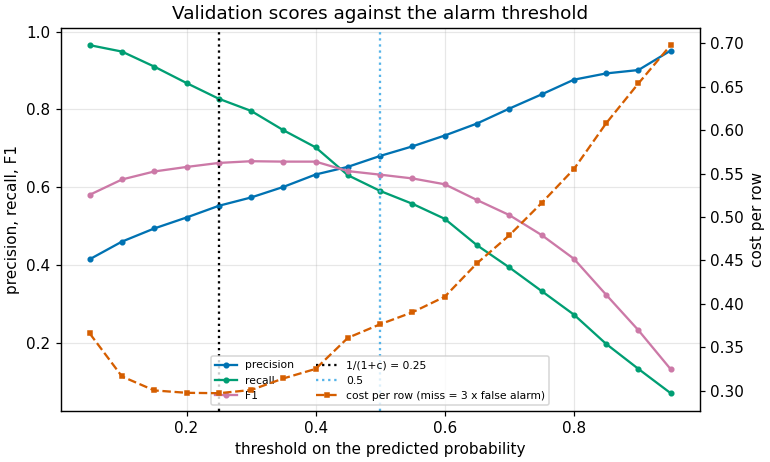

In [62]:
print("cost ratio (miss : false alarm):", p5["cost_ratio"], "| 1/(1+c) =", p5["t_cost"])
print("grid threshold with the lowest validation cost:", p5["t_cost_empirical"],
      "| with the highest F1:", p5["t_f1"])
show(plot_threshold_curve(p5))

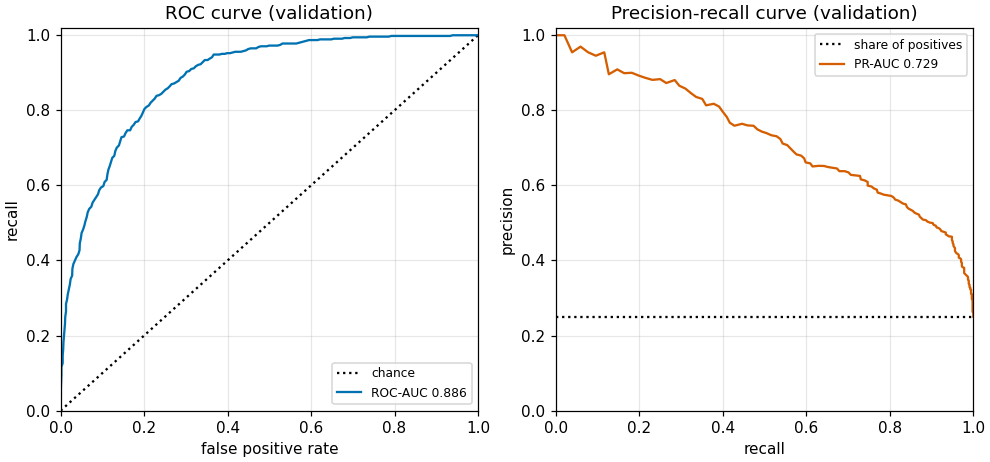

In [63]:
show(plot_roc_pr(p5))

largest gap between predicted and observed share (bins with >= 30 rows): 0.1036


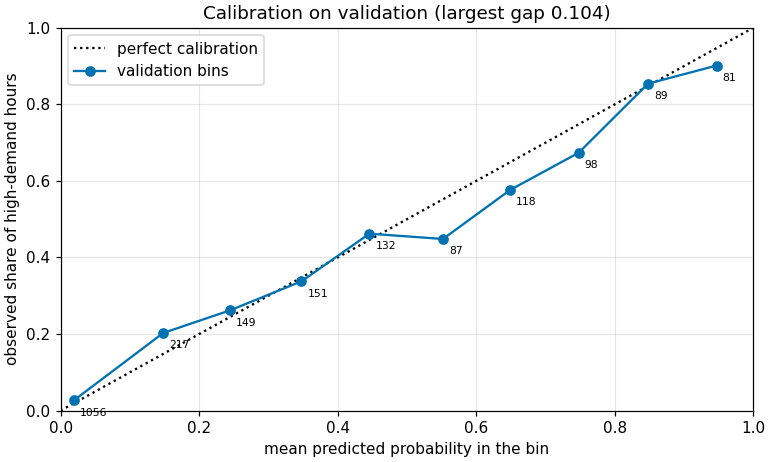

In [64]:
print("largest gap between predicted and observed share (bins with >= 30 rows):", round(p5["calibration_max_gap"], 4))
show(plot_calibration(p5))

In [65]:
# What the classifier relies on: the largest standardised weights, and the share of sum|w| by original column.
print(pd.DataFrame(p5["top_coefficients"]).round(3).to_string(index=False))
print("\nshare of sum|w| by original column:")
print(pd.Series(p5["coef_abs_share_by_column"]).round(3).to_string())

     name  weight
     temp   2.593
   temp^2  -1.120
   temp^3  -1.043
   doy_s1  -0.906
   doy_c1  -0.711
wk_2*hr_6   0.514
wk_2*hr_9   0.500
wk_2*hr_7   0.478
      hum  -0.471
wk_2*hr_8   0.461
wk_3*hr_6   0.450
wk_5*hr_3  -0.438
   doy_s2  -0.428
hr_3*temp  -0.423
wk_3*hr_8   0.422

share of sum|w| by original column:
dteday        0.040
hr            0.428
hum           0.038
temp          0.149
weathersit    0.023
weekday       0.271
windspeed     0.005
workingday    0.047


### Pipeline retrospective

Each phase used what the previous one produced, and the table below is built from the five artifact files.

- **Phase 1** gave a working optimiser and an honest baseline: validation R² 0.721 with 36 weights. Its residuals showed the missing structure.
- **Phase 2** started from Phase 1's weights (first loss equal to Phase 1's last) and added what those residuals asked for: R² 0.910.
- **Phase 3** showed that this model was still too simple, not too flexible, and that the gap to a chronological split is drift rather than leakage. It moved the target to 282 weights: 0.939 on validation, 0.943 on held-out days, 0.914 chronologically.
- **Phase 4** found, as that diagnosis implies, that penalties change little (all three methods within noise of each other), used them to sort the 14 columns into useful, redundant and uninformative, and recommended enet on the 279 surviving features: R² 0.939, RMSE 45.5.
- **Phase 5** reused exactly those features for a classifier: ROC-AUC 0.886, F1 0.663, accuracy 0.789 at the cost-based cut-off.

The thread through all five: on this data the errors come from bias. Every gain came from giving the linear model structure the data really has; the classical variance cures (higher degree, stronger penalty) did nothing measurable. **The regression model our pipeline recommends, and the one behind our submission, is the Phase 4 stage-B model.**

In [66]:
retro = pd.DataFrame(p5["retrospective"])
print(retro[["phase", "n_features", "train_score", "val_score", "val_rmse"]].round(4).to_string(index=False))
print()
for _, row in retro.iterrows():
    print(f"{row['phase']}: consumed {row['consumed']}; settings {row['hyperparameters']}" +
          (f"; {row['extra']}" if row["extra"] else ""))

              phase  n_features  train_score  val_score  val_rmse
P1 gradient descent          36       0.7293     0.7212   97.3189
      P2 polynomial          61       0.9121     0.9105   55.1504
   P3 bias-variance         282       0.9471     0.9390   45.5212
  P4 regularization         280          NaN     0.9390   45.5173
        P5 logistic         280       0.9151     0.8859       NaN

P1 gradient descent: consumed 35 base columns + bias, log1p target; settings lr=0.506, 474 iterations
P2 polynomial: consumed P1 weights as the starting point; settings degree=3 on temp, blocks=wd_x_hr; gain over P1 = 0.1893 R2
P3 bias-variance: consumed P2 design as anchor of a 11-level ladder; settings target C6_weather_detail (282 weights); target seeded/day-block/chrono = 0.939/0.943/0.914; anchor = 0.910/0.909/0.858
P4 regularization: consumed P3 target design + 6 candidate columns; settings l2 lambda=4.92e-06 val_r2=0.9382; l1 lambda=0.000182 val_r2=0.9382; enet lambda=0.000607 val_r2=0.938

## Outcome — Phase 5

**What happened.**
- Class balance is as planned: 0.246 positives in training, 0.250 in validation, 0.239 and 0.262 by year.
- The foils behaved as predicted: global threshold, hour-only AUC 0.855 and full model 0.986; our rule, hour-only 0.502.
- Our classifier: ROC-AUC 0.886 (95% interval 0.870–0.900), PR-AUC 0.729. At the cut-off 0.25: accuracy 0.789, F1 0.663, precision 0.553, recall 0.828. At 0.5: accuracy 0.828, F1 0.633, recall 0.591.
- The cost argument holds up: at 0.25 we miss 94 high-demand hours and raise 365 false alarms (cost 0.297 per hour); at 0.5 we would miss 223 (cost 0.376).

**What surprised us.**
- Accuracy is *lower* at our chosen cut-off (0.789) than at 0.5 (0.828), and barely above the do-nothing baseline of 0.750. Judged by accuracy alone our operating point looks like a mistake; judged by the operator's cost it is clearly the better one. This is the clearest case in the project of a metric pointing the wrong way.
- The cost argument held more exactly than we expected: on our grid the validation cost is lowest at 0.25, the theoretical value, even though the probabilities are not perfectly calibrated (largest gap 0.104). We did not tune the cut-off on the validation rows.
- The honest task is much harder than the trivial one (AUC 0.886 against 0.986). Whether an hour is unusually busy for its slot depends on things we only partly observe: the weather explains some of it, events and school holidays are not in the data.
- Even with the label made relative to the hour, hour-related columns still carry a large share of the weights (table above): the weather effect differs by hour, so the survivors' hour × weather interactions matter even though the hour alone predicts nothing.

## Phase 6 — Final model and submission

**Which model.** The regression model our pipeline recommends is the Phase 4 stage-B model: enet with λ = 7.7e-04 and l1_ratio 0.3 on the surviving features. Nothing is tuned here.

**Refit on training + validation, and why.** The hyper-parameters stay exactly as validated, but the weights are refitted on all 10886 labelled rows. The Phase 3 learning curve of the target was still rising at full size (0.937 with 80% of the training days, 0.939 with all of them), so a quarter more rows should help a little, and the validation rows are days of the same months as the hidden ones. The scaler and the humidity fill stay as fitted on the training portion, so the hidden rows go through exactly the transformations used everywhere else. The cell first refits the validated model on the training rows alone and asserts that it reproduces the Phase 4 weights.

**What we check without labels.** We cannot score the hidden days, and we do not tune anything on them. We only check that the predictions are sane: same rows and order as `test.csv`, no missing or negative values, the refitted model agrees closely with the validated one (correlation 0.9997), and the predicted hourly profile by day type looks like the training profile (each cell between 0.77 and 1.08 times the training mean).

**What the model cannot adapt to.** It extrapolates growth as a straight line in log space, which Phase 3 showed to be too steep beyond the observed period; it has never seen a zero-demand hour, weather outside the observed range, or holidays other than those in the training days. For the hidden days, which lie inside the two observed years, the held-out-day estimate of Phase 4 (0.943) is our best guess of the score; for a genuinely later period we would expect something nearer the chronological estimate (0.914).

In [67]:
# Phase 6 reads artifacts/p4.json (the recommended regression model on the surviving columns), refits it on training
# plus validation rows and predicts the hidden days. It does not re-run any earlier phase.
import numpy as np
import pandas as pd

from src import predict
from src.common import config_seed, load_config, load_test, load_train, read_artifact, sha256_file
from src.plots_p5 import plot_test_profile

CFG = globals().get("CFG") or load_config()
p6 = predict.run(CFG)  # writes sample_submission.csv and artifacts/p6.json

In [68]:
# What was submitted and how it compares with the model that was validated (model A, training rows only).
summary = {
    "model (Phase 4 recommended)": p6["model"]["method"],
    "lambda": p6["model"]["lambda"],
    "l1_ratio": p6["model"]["l1_ratio"],
    "refit on": p6["refit_on"],
    "rows used to fit": p6["n_fit_rows"],
    "rows predicted": p6["n_test_rows"],
    "model A reproduces the Phase 4 weights (max gap)": p6["model_a_gap_to_p4"],
    "prediction mean": p6["pred"]["mean"],
    "prediction median": p6["pred"]["median"],
    "prediction min": p6["pred"]["min"],
    "prediction max": p6["pred"]["max"],
    "predictions below 1 bike": p6["pred"]["n_below_1"],
    "predictions clipped at 0": p6["pred"]["n_clipped"],
    "mean cnt of the training rows": p6["train_cnt_mean"],
    "A versus B on the hidden rows: correlation": p6["a_vs_b_on_test"]["corr"],
    "A versus B: mean ratio B / A": p6["a_vs_b_on_test"]["mean_ratio"],
    "A versus B: mean absolute difference": p6["a_vs_b_on_test"]["mean_abs_diff"],
    "A versus B: largest absolute difference": p6["a_vs_b_on_test"]["max_abs_diff"],
    "profile ratio min / max (per day type and hour)": f"{p6['profile_ratio']['min']:.3f} / {p6['profile_ratio']['max']:.3f}",
    "cells outside 0.4-2.5": p6["profile_ratio"]["cells_outside_0_4_2_5"],
    "daily-total ratio min / max": f"{p6['daily_total_ratio']['min']:.3f} / {p6['daily_total_ratio']['max']:.3f}",
    "mean prediction 2011 / 2012": f"{p6['by_year_mean']['0']:.1f} / {p6['by_year_mean']['1']:.1f}",
}
print(pd.Series(summary, name="value").to_string())

model (Phase 4 recommended)                                     enet
lambda                                                      0.000768
l1_ratio                                                         0.3
refit on                                            train+validation
rows used to fit                                               10886
rows predicted                                                   574
model A reproduces the Phase 4 weights (max gap)                 0.0
prediction mean                                           197.566742
prediction median                                            155.435
prediction min                                                  1.39
prediction max                                                934.23
predictions below 1 bike                                           0
predictions clipped at 0                                           0
mean cnt of the training rows                             191.607487
A versus B on the hidden rows: cor

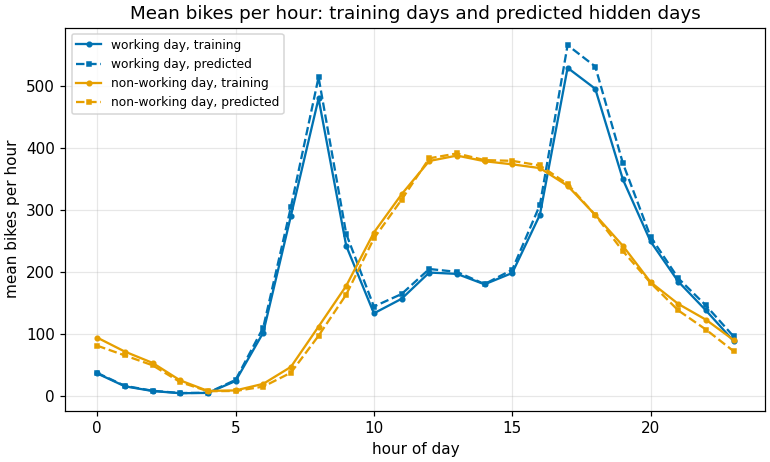

In [69]:
labelled_df, test_df = load_train(CFG), load_test(CFG)
sub = pd.read_csv(predict.SUBMISSION_PATH)
from src.plots import show  # displays a figure as a PNG in the notebook
show(plot_test_profile(labelled_df, test_df, sub))

In [70]:
# The same checks as tools/submission_check.py, inline (hard failures are asserts).
assert list(sub.columns) == ["instant", "cnt"], list(sub.columns)
assert len(sub) == len(test_df), (len(sub), len(test_df))
assert (sub["instant"].to_numpy() == test_df["instant"].to_numpy()).all(), "row order differs from the hidden file"
assert np.isfinite(sub["cnt"].to_numpy(dtype=float)).all(), "NaN or inf in cnt"
assert (sub["cnt"] >= 0).all(), "negative predictions"
assert not (sub["cnt"] == 0).all(), "all predictions are 0"
print("submission:", sub.shape, "| columns", list(sub.columns), "| order equals the hidden file | no NaN | no negatives")
print("cells outside the 0.4-2.5 band of the training profile:", p6["profile_ratio"]["cells_outside_0_4_2_5"],
      "| daily totals vs same-month training days:", round(p6["daily_total_ratio"]["min"], 2), "to",
      round(p6["daily_total_ratio"]["max"], 2))

submission: (574, 2) | columns ['instant', 'cnt'] | order equals the hidden file | no NaN | no negatives
cells outside the 0.4-2.5 band of the training profile: 0 | daily totals vs same-month training days: 0.82 to 1.49


In [71]:
# All chain assertions in one table: hash chain p1 -> p6, shared seed, Phase 2 start loss = Phase 1 final loss,
# Phase 5 features among the Phase 4 survivors, model A reproduces Phase 4.
arts = {name: read_artifact(name) for name in ("p1", "p2", "p3", "p4", "p5", "p6")}
checks = []
for prev, name in zip(("p1", "p2", "p3", "p4", "p5"), ("p2", "p3", "p4", "p5", "p6")):
    checks.append((f"{name}.upstream_sha256 == sha256(artifacts/{prev}.json)",
                   arts[name]["upstream_sha256"] == sha256_file(f"artifacts/{prev}.json")))
checks.append(("p1 has no upstream", arts["p1"]["upstream_sha256"] is None))
checks.append(("same seed in p1..p6 and equal to the seed of the config",
               {a["seed"] for a in arts.values()} == {config_seed(CFG)}))
checks.append(("p2 starts from the p1 weights", arts["p2"]["init_weights_source"] == "p1"))
checks.append(("p2.init_loss == p1.train_loss_final (1e-9)",
               abs(arts["p2"]["init_loss"] - arts["p1"]["train_loss_final"]) <= 1e-9 * max(1.0, arts["p1"]["train_loss_final"])))
checks.append(("p5.features are a subset of p4.survivors_expanded",
               set(arts["p5"]["features"]) <= set(arts["p4"]["survivors_expanded"])))
checks.append(("p4.recommended was fitted on the survivors, p6 uses the same columns",
               arts["p4"]["recommended"].get("fitted_on") == "survivors"))
checks.append(("model A reproduces the p4 weights (< 1e-6)", arts["p6"]["model_a_gap_to_p4"] < 1e-6))
checks.append(("p5 chosen model converged", arts["p5"]["stop_reason"] == "converged"))
report = pd.DataFrame(checks, columns=["assertion", "holds"])
print(report.to_string(index=False))
assert report["holds"].all(), "a chain assertion failed"

                                                           assertion  holds
                     p2.upstream_sha256 == sha256(artifacts/p1.json)   True
                     p3.upstream_sha256 == sha256(artifacts/p2.json)   True
                     p4.upstream_sha256 == sha256(artifacts/p3.json)   True
                     p5.upstream_sha256 == sha256(artifacts/p4.json)   True
                     p6.upstream_sha256 == sha256(artifacts/p5.json)   True
                                                  p1 has no upstream   True
             same seed in p1..p6 and equal to the seed of the config   True
                                       p2 starts from the p1 weights   True
                          p2.init_loss == p1.train_loss_final (1e-9)   True
                   p5.features are a subset of p4.survivors_expanded   True
p4.recommended was fitted on the survivors, p6 uses the same columns   True
                          model A reproduces the p4 weights (< 1e-6)   True
            